# Configurare si importuri

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install distrax
!pip install optax
!pip install orbax-checkpoint

In [ ]:
import jax
import jax.numpy as jnp
from typing import NamedTuple, Callable
from jax.tree_util import register_pytree_node

import flax.linen as nn
from flax.linen.initializers import orthogonal, constant, normal
from flax.training.train_state import TrainState
from flax.training import checkpoints

import orbax.checkpoint as ocp

import matplotlib.pyplot as plt
from functools import partial
import numpy as np
import os

import optax
import distrax

import time

# Cipher related functions

In [ ]:
class Cipher(NamedTuple):
    name: str
    n_rounds: int
    state_size: int
    num_sboxes: int
    sbox_bits: int
    sbox: jnp.ndarray
    p_map: jnp.ndarray
    log_probs: jnp.ndarray
    valid_mask: jnp.ndarray
    linear_layer: Callable    # a function pointer for the linear layer
    shifts: jnp.ndarray       # For nibble-level operations
    bit_indices: jnp.ndarray  # For bit-level permutation
    precalc_tables: jnp.ndarray

# Register Cipher as a Pytree so JAX knows how to handle the arrays inside it
register_pytree_node(
    Cipher,
    # Children: Things that are JAX arrays (must be moved to GPU)
    # ADDED x.precalc_tables to the end of this tuple
    lambda x: ((x.sbox, x.p_map, x.log_probs, x.valid_mask, x.shifts, x.bit_indices, x.precalc_tables),
               (x.name, x.n_rounds, x.state_size, x.num_sboxes, x.sbox_bits, x.linear_layer)),

    # Aux: Static metadata (strings, ints, function pointers)
    lambda aux, children: Cipher(
        name=aux[0], n_rounds=aux[1], state_size=aux[2],
        num_sboxes=aux[3], sbox_bits=aux[4],
        sbox=children[0], p_map=children[1], log_probs=children[2],
        valid_mask=children[3], shifts=children[4], bit_indices=children[5],
        precalc_tables=children[6], # <--- ADDED THIS LINE
        linear_layer=aux[5]
    )
)

In [ ]:
def initialize_cipher_tables(sbox, threshold=0.125, penalty=-100.0):
    """
    Computes both Log Probs and Valid Mask in a single pass.
    Optimized for AES-sized S-boxes.
    """
    size = len(sbox)
    ddt = np.zeros((size, size), dtype=np.int32)

    # 1. Compute the DDT
    for in_diff in range(size):
        # Vectorized internal loop: compute all out_diffs for a fixed in_diff
        x1 = np.arange(size)
        x2 = x1 ^ in_diff
        # Apply S-box to both (vectorized)
        sbox_x1 = np.array([sbox[val] for val in x1])
        sbox_x2 = np.array([sbox[val] for val in x2])
        out_diffs = sbox_x1 ^ sbox_x2

        # Count occurrences
        counts = np.bincount(out_diffs, minlength=size)
        ddt[in_diff] = counts

    # 2. Convert to Probabilities
    probs = ddt.astype(np.float32) / size

    # 3. Create the Valid Mask
    # True if prob exists and meets threshold
    valid_mask = probs >= threshold

    # 4. Compute Log2 Probs
    with np.errstate(divide='ignore'):
        log_probs = np.log2(probs)

    # 5. Apply Pruning/Penalty
    # Any transition that is invalid gets the penalty
    log_probs = np.where(valid_mask, log_probs, penalty)

    # print(f"Tables initialized. Max prob: 2^{np.max(log_probs[log_probs > penalty]):.2f}")
    print(f"Tables initialized. Max prob: 2^{np.max(log_probs.ravel()[1:]):.2f}")
    return jnp.array(log_probs), jnp.array(valid_mask)


In [ ]:
@jax.jit
def universal_bit_permutation_layer_fast(state_array: jnp.ndarray, cipher):
    p_map = cipher.precalc_tables # The flat 1D bit permutation map

    # 1. Vectorized Unpacking
    bit_shifts = jnp.arange(cipher.sbox_bits, dtype=jnp.uint32)
    bits = (state_array[..., None] >> bit_shifts) & 1

    # 2. Flatten and Permute
    flat_bits = bits.reshape(bits.shape[:-2] + (-1,))
    permuted_bits = flat_bits[..., p_map]

    # 3. Re-pack into Nibbles
    reshaped_permuted = permuted_bits.reshape(bits.shape)
    return jnp.sum(reshaped_permuted << bit_shifts, axis=-1).astype(jnp.uint32)

@jax.jit
def skinny_linear_layer_fast(state_array: jnp.ndarray, cipher):
    # ShiftRows using the p_map
    shifted = state_array[..., cipher.p_map]
    grid = shifted.reshape(shifted.shape[:-1] + (4, 4))

    r0, r1, r2, r3 = grid[..., 0, :], grid[..., 1, :], grid[..., 2, :], grid[..., 3, :]

    # SKINNY MixColumns Matrix
    out0 = r0 ^ r2 ^ r3
    out1 = r0
    out2 = r1 ^ r2
    out3 = r0 ^ r2

    return jnp.stack([out0, out1, out2, out3], axis=-2).reshape(state_array.shape)

@jax.jit
def aes_linear_layer_fast(state_array: jnp.ndarray, cipher):
    # Lookup tables: cipher.precalc_tables[0] is mul2, [1] is mul3
    m2 = cipher.precalc_tables[0]
    m3 = cipher.precalc_tables[1]

    # 1. ShiftRows
    shifted = state_array[..., cipher.p_map]
    grid = shifted.reshape(shifted.shape[:-1] + (4, 4))

    # 2. MixColumns (Column-wise GF matrix multiplication)
    r0, r1, r2, r3 = grid[..., 0, :], grid[..., 1, :], grid[..., 2, :], grid[..., 3, :]

    out0 = m2[r0] ^ m3[r1] ^ r2 ^ r3
    out1 = r0 ^ m2[r1] ^ m3[r2] ^ r3
    out2 = r0 ^ r1 ^ m2[r2] ^ m3[r3]
    out3 = m3[r0] ^ r1 ^ r2 ^ m2[r3]

    # 3. Re-pack
    return jnp.stack([out0, out1, out2, out3], axis=-2).reshape(state_array.shape)

# Cipher initializations

### Toy cipher

In [ ]:
# ==========================================
# TOY CIPHER (16-bit state, 4-bit S-box)
# ==========================================
toy_num_sboxes = 4
toy_sbox_bits = 4
toy_state_size = 16

toy_shifts = jnp.arange(toy_num_sboxes, dtype=jnp.uint32) * jnp.uint32(toy_sbox_bits)
toy_bit_indices = jnp.arange(toy_state_size, dtype=jnp.uint32)

toy_sbox = jnp.array([0xE, 0x4, 0xD, 0x1, 0x2, 0xF, 0xB, 0x8, 0x3, 0xA, 0x6, 0xC, 0x5, 0x9, 0x0, 0x7], dtype=jnp.uint32)
toy_p_map = jnp.array([0, 4, 8, 12, 1, 5, 9, 13, 2, 6, 10, 14, 3, 7, 11, 15], dtype=jnp.int32)
toy_p_map_origin = jnp.argsort(toy_p_map)

toy_log_probs, toy_valid_mask = initialize_cipher_tables(toy_sbox, threshold=0.125)

toy_cipher_instance = Cipher(
    name="Toy_16Bit",
    n_rounds=3,
    state_size=toy_state_size,
    num_sboxes=toy_num_sboxes,
    sbox_bits=toy_sbox_bits,
    sbox=toy_sbox,
    p_map=toy_p_map_origin,
    log_probs=toy_log_probs,
    valid_mask=toy_valid_mask,
    linear_layer=universal_bit_permutation_layer_fast, # Uses the universal bit-level permutation
    shifts=toy_shifts,
    bit_indices=toy_bit_indices,
    precalc_tables=toy_p_map_origin
)

Tables initialized. Max prob: 2^0.00


### Present cipher

In [ ]:
# ==========================================
# PRESENT CIPHER (64-bit state, 4-bit S-box)
# ==========================================
present_num_sboxes = 16
present_sbox_bits = 4
present_state_size = 64

present_shifts = jnp.arange(present_num_sboxes, dtype=jnp.uint32) * jnp.uint32(present_sbox_bits)
present_bit_indices = jnp.arange(present_state_size, dtype=jnp.uint32)

present_sbox = jnp.array([0xC, 0x5, 0x6, 0xB, 0x9, 0x0, 0xA, 0xD, 0x3, 0xE, 0xF, 0x8, 0x4, 0x7, 0x1, 0x2], dtype=jnp.uint32)
present_p_map_dest = jnp.array([
    0, 16, 32, 48, 1, 17, 33, 49, 2, 18, 34, 50, 3, 19, 35, 51,
    4, 20, 36, 52, 5, 21, 37, 53, 6, 22, 38, 54, 7, 23, 39, 55,
    8, 24, 40, 56, 9, 25, 41, 57, 10, 26, 42, 58, 11, 27, 43, 59,
    12, 28, 44, 60, 13, 29, 45, 61, 14, 30, 46, 62, 15, 31, 47, 63
], dtype=jnp.int32)

# FIX: Invert the map so it works with JAX's origin-based indexing
# This calculates: "At which position did the bit at index i end up?"
present_p_map_origin = jnp.argsort(present_p_map_dest)

# present_log_probs = initialize_ddt_log_probs(present_sbox)
# present_valid_mask = initialize_valid_mask(present_sbox)

present_log_probs, present_valid_mask = initialize_cipher_tables(present_sbox, threshold=0.125)
present_precalc = present_p_map_origin

present_cipher_instance = Cipher(
    name="Present_64Bit",
    n_rounds=6,
    state_size=present_state_size,
    num_sboxes=present_num_sboxes,
    sbox_bits=present_sbox_bits,
    sbox=present_sbox,
    p_map=present_p_map_origin,
    log_probs=present_log_probs,
    valid_mask=present_valid_mask,
    linear_layer=universal_bit_permutation_layer_fast, # Uses the universal bit-level permutation
    shifts=present_shifts,
    bit_indices=present_bit_indices,
    precalc_tables=present_precalc
)

Tables initialized. Max prob: 2^-2.00


### Skinny cipher

In [ ]:
# ==========================================
# SKINNY-64 CIPHER (64-bit state, 4-bit S-box)
# ==========================================
skinny_num_sboxes = 16
skinny_sbox_bits = 4
skinny_state_size = 64

skinny_shifts = jnp.arange(skinny_num_sboxes, dtype=jnp.uint32) * jnp.uint32(skinny_sbox_bits)
skinny_bit_indices = jnp.arange(skinny_state_size, dtype=jnp.uint32)

# SKINNY 4-bit S-box
skinny_sbox = jnp.array([0xC, 0x6, 0x9, 0x0, 0x1, 0xA, 0x2, 0xB, 0x3, 0x8, 0x5, 0xD, 0x4, 0xE, 0x7, 0xF], dtype=jnp.uint32)

# SKINNY ShiftRows Permutation Map
skinny_p_map = jnp.array([
    0, 1, 2, 3,       # Row 0: No shift
    7, 4, 5, 6,       # Row 1: Right shift 1
    10, 11, 8, 9,     # Row 2: Right shift 2
    13, 14, 15, 12    # Row 3: Right shift 3
], dtype=jnp.int32)

# skinny_log_probs = initialize_ddt_log_probs(skinny_sbox)
# skinny_valid_mask = initialize_valid_mask(skinny_sbox)

skinny_log_probs, skinny_valid_mask = initialize_cipher_tables(skinny_sbox, threshold=0.125)


skinny_cipher_instance = Cipher(
    name="Skinny_64Bit",
    n_rounds=7,
    state_size=skinny_state_size,
    num_sboxes=skinny_num_sboxes,
    sbox_bits=skinny_sbox_bits,
    sbox=skinny_sbox,
    p_map=skinny_p_map,
    log_probs=skinny_log_probs,
    valid_mask=skinny_valid_mask,
    linear_layer=skinny_linear_layer_fast,
    shifts=skinny_shifts,
    bit_indices=skinny_bit_indices,
    precalc_tables=jnp.array([])
)

Tables initialized. Max prob: 2^-2.00


### AES cipher

In [ ]:
# ==========================================
# AES-128 CIPHER (128-bit state, 8-bit S-box)
# ==========================================
aes_num_sboxes = 16
aes_sbox_bits = 8
aes_state_size = 128

aes_shifts = jnp.arange(aes_num_sboxes, dtype=jnp.uint32) * jnp.uint32(aes_sbox_bits)
aes_bit_indices = jnp.arange(aes_state_size, dtype=jnp.uint32)

# Standard 256-element AES S-box
aes_sbox = jnp.array([
    0x63, 0x7C, 0x77, 0x7B, 0xF2, 0x6B, 0x6F, 0xC5, 0x30, 0x01, 0x67, 0x2B, 0xFE, 0xD7, 0xAB, 0x76,
    0xCA, 0x82, 0xC9, 0x7D, 0xFA, 0x59, 0x47, 0xF0, 0xAD, 0xD4, 0xA2, 0xAF, 0x9C, 0xA4, 0x72, 0xC0,
    0xB7, 0xFD, 0x93, 0x26, 0x36, 0x3F, 0xF7, 0xCC, 0x34, 0xA5, 0xE5, 0xF1, 0x71, 0xD8, 0x31, 0x15,
    0x04, 0xC7, 0x23, 0xC3, 0x18, 0x96, 0x05, 0x9A, 0x07, 0x12, 0x80, 0xE2, 0xEB, 0x27, 0xB2, 0x75,
    0x09, 0x83, 0x2C, 0x1A, 0x1B, 0x6E, 0x5A, 0xA0, 0x52, 0x3B, 0xD6, 0xB3, 0x29, 0xE3, 0x2F, 0x84,
    0x53, 0xD1, 0x00, 0xED, 0x20, 0xFC, 0xB1, 0x5B, 0x6A, 0xCB, 0xBE, 0x39, 0x4A, 0x4C, 0x58, 0xCF,
    0xD0, 0xEF, 0xAA, 0xFB, 0x43, 0x4D, 0x33, 0x85, 0x45, 0xF9, 0x02, 0x7F, 0x50, 0x3C, 0x9F, 0xA8,
    0x51, 0xA3, 0x40, 0x8F, 0x92, 0x9D, 0x38, 0xF5, 0xBC, 0xB6, 0xDA, 0x21, 0x10, 0xFF, 0xF3, 0xD2,
    0xCD, 0x0C, 0x13, 0xEC, 0x5F, 0x97, 0x44, 0x17, 0xC4, 0xA7, 0x7E, 0x3D, 0x64, 0x5D, 0x19, 0x73,
    0x60, 0x81, 0x4F, 0xDC, 0x22, 0x2A, 0x90, 0x88, 0x46, 0xEE, 0xB8, 0x14, 0xDE, 0x5E, 0x0B, 0xDB,
    0xE0, 0x32, 0x3A, 0x0A, 0x49, 0x06, 0x24, 0x5C, 0xC2, 0xD3, 0xAC, 0x62, 0x91, 0x95, 0xE4, 0x79,
    0xE7, 0xC8, 0x37, 0x6D, 0x8D, 0xD5, 0x4E, 0xA9, 0x6C, 0x56, 0xF4, 0xEA, 0x65, 0x7A, 0xAE, 0x08,
    0xBA, 0x78, 0x25, 0x2E, 0x1C, 0xA6, 0xB4, 0xC6, 0xE8, 0xDD, 0x74, 0x1F, 0x4B, 0xBD, 0x8B, 0x8A,
    0x70, 0x3E, 0xB5, 0x66, 0x48, 0x03, 0xF6, 0x0E, 0x61, 0x35, 0x57, 0xB9, 0x86, 0xC1, 0x1D, 0x9E,
    0xE1, 0xF8, 0x98, 0x11, 0x69, 0xD9, 0x8E, 0x94, 0x9B, 0x1E, 0x87, 0xE9, 0xCE, 0x55, 0x28, 0xDF,
    0x8C, 0xA1, 0x89, 0x0D, 0xBF, 0xE6, 0x42, 0x68, 0x41, 0x99, 0x2D, 0x0F, 0xB0, 0x54, 0xBB, 0x16
], dtype=jnp.uint32)

# AES ShiftRows Permutation Map
aes_p_map = jnp.array([
    0, 1, 2, 3,       # Row 0: No shift
    5, 6, 7, 4,       # Row 1: Left shift 1
    10, 11, 8, 9,     # Row 2: Left shift 2
    15, 12, 13, 14    # Row 3: Left shift 3
], dtype=jnp.int32)

# aes_log_probs = initialize_ddt_log_probs(aes_sbox)
# aes_valid_mask = initialize_valid_mask(aes_sbox)

aes_log_probs, aes_valid_mask = initialize_cipher_tables(aes_sbox, threshold=0.0039)
jnp.save("aes_log_probs.npy", aes_log_probs)
jnp.save("aes_valid_mask.npy", aes_valid_mask)

# 1. Create an array of all 256 possible byte values (0 to 255)
_x = jnp.arange(256, dtype=jnp.uint32)

# 2. Vectorized GF(2^8) multiplication by 2
# Shift left by 1. If the original high bit (0x80) was 1, XOR with 0x1B
aes_mul2 = jnp.where(_x & 0x80, (_x << 1) ^ 0x1B, _x << 1) & 0xFF

# 3. Vectorized GF(2^8) multiplication by 3
# In GF(2^8), x * 3 is mathematically equivalent to (x * 2) XOR x
aes_mul3 = aes_mul2 ^ _x

# 4. Stack them into the precalc table array (Shape: 2, 256)
aes_precalc = jnp.stack([aes_mul2, aes_mul3])

aes_cipher_instance = Cipher(
    name="AES_128Bit",
    n_rounds=4,
    state_size=aes_state_size,
    num_sboxes=aes_num_sboxes,
    sbox_bits=aes_sbox_bits,
    sbox=aes_sbox,
    p_map=aes_p_map,
    log_probs=aes_log_probs,
    valid_mask=aes_valid_mask,
    linear_layer=aes_linear_layer_fast, # Points to the AES GF(2^8) Matrix
    shifts=aes_shifts,
    bit_indices=aes_bit_indices,
    precalc_tables=aes_precalc
)

Tables initialized. Max prob: 2^0.00


# Actor&Critic neural network  - MLP, CNN

In [ ]:
# class ActorCritic(nn.Module):
#     num_sboxes: int
#     action_dim: int  # 16 for a 4-bit S-box

#     @nn.compact
#     def __call__(self, x):
#         # x is the bit-vector [batch_size, state_size]

#         # Shared Feature Extractor
#         x = nn.Dense(256, kernel_init=orthogonal(jnp.sqrt(2)), bias_init=constant(0.0))(x)
#         # x = nn.Dense(512, kernel_init=orthogonal(jnp.sqrt(2)), bias_init=constant(0.0))(x)

#         x = nn.relu(x)
#         x = nn.Dense(256, kernel_init=orthogonal(jnp.sqrt(2)), bias_init=constant(0.0))(x)
#         # x = nn.Dense(512, kernel_init=orthogonal(jnp.sqrt(2)), bias_init=constant(0.0))(x)

#         x = nn.relu(x)

#         # --- ACTOR HEAD ---
#         # We need an output for EACH S-box.
#         # Shape: [batch_size, num_sboxes * action_dim]
#         actor_logits = nn.Dense(self.num_sboxes * self.action_dim,
#                                 kernel_init=orthogonal(0.01),
#                                 bias_init=constant(0.0))(x)

#         # Reshape to [batch_size, num_sboxes, action_dim]
#         actor_logits = actor_logits.reshape((-1, self.num_sboxes, self.action_dim))

#         # Categorical distribution for each S-box
#         pi = distrax.Categorical(logits=actor_logits)

#         # --- CRITIC HEAD ---
#         critic_value = nn.Dense(1, kernel_init=orthogonal(1.0), bias_init=constant(0.0))(x)

#         return pi, jnp.squeeze(critic_value, axis=-1)

class PresentActorCritic(nn.Module):
    num_sboxes: int
    sbox_bits: int
    action_dim: int

    @nn.compact
    def __call__(self, x):
        # x shape: [batch, total_features]
        bit_size = self.num_sboxes * self.sbox_bits
        state_bits = x[:, :bit_size]
        meta_feats = x[:, bit_size:]

        # 1. Reshape for Conv
        nibbles = state_bits.reshape((-1, self.num_sboxes, self.sbox_bits))

        # 2. Local Feature Extraction
        x_conv = nn.Conv(features=32, kernel_size=(1,), strides=(1,))(nibbles)
        x_conv = nn.relu(x_conv)

        # 3. FIX: Replace nn.Flatten() with JAX reshape
        # This collapses [batch, num_sboxes, features] into [batch, num_sboxes * features]
        x_flat = x_conv.reshape((x_conv.shape[0], -1))

        # 4. Merge metadata
        combined = jnp.concatenate([x_flat, meta_feats], axis=-1)

        # Shared Dense Layers
        z = nn.Dense(256, kernel_init=orthogonal(jnp.sqrt(2)))(combined)
        z = nn.relu(z)
        z = nn.Dense(256, kernel_init=orthogonal(jnp.sqrt(2)))(z)
        z = nn.relu(z)

        # Actor/Critic Heads
        actor_logits = nn.Dense(self.num_sboxes * self.action_dim, kernel_init=orthogonal(0.01))(z)
        actor_logits = actor_logits.reshape((-1, self.num_sboxes, self.action_dim))
        pi = distrax.Categorical(logits=actor_logits)

        critic_value = nn.Dense(1, kernel_init=orthogonal(1.0))(z)

        return pi, jnp.squeeze(critic_value, axis=-1)



# Self attention actor&critic network - transformer based

In [ ]:
class TransformerBlock(nn.Module):
    num_heads: int
    qkv_features: int
    mlp_dim: int

    @nn.compact
    def __call__(self, x):
        # --- Pre-LayerNorm Architecture ---

        # 1. Multi-Head Self Attention (Normalize BEFORE Attention)
        attn_in = nn.LayerNorm()(x)
        attn_out = nn.MultiHeadDotProductAttention(
            num_heads=self.num_heads,
            qkv_features=self.qkv_features,
            out_features=x.shape[-1],
            kernel_init=orthogonal(jnp.sqrt(2))
        )(attn_in, attn_in)

        # Residual connection
        x = x + attn_out

        # 2. MLP Block (Normalize BEFORE MLP)
        mlp_in = nn.LayerNorm()(x)
        mlp_out = nn.Dense(self.mlp_dim, kernel_init=orthogonal(jnp.sqrt(2)))(mlp_in)
        mlp_out = nn.relu(mlp_out)
        mlp_out = nn.Dense(x.shape[-1], kernel_init=orthogonal(jnp.sqrt(2)))(mlp_out)

        # Residual connection
        x = x + mlp_out

        return x

class AttentionUniversalActorCritic(nn.Module):
    num_sboxes: int
    sbox_bits: int
    action_dim: int
    d_model: int = 32         # Size of the embedding for each nibble
    num_tf_blocks: int = 1    # Number of stacked Transformer blocks

    @nn.compact
    def __call__(self, x):
        # x shape: [batch, total_features]
        bit_size = self.num_sboxes * self.sbox_bits
        state_bits = x[:, :bit_size]
        meta_feats = x[:, bit_size:]

        # 1. Sequence Reshape: e.g. [batch, 16, 4] or [batch, 16, 8]
        seq = state_bits.reshape((-1, self.num_sboxes, self.sbox_bits))

        # 2. Linear Projection (Embed the bits into d_model dimensions)
        seq = nn.Dense(self.d_model, kernel_init=orthogonal(jnp.sqrt(2)))(seq)

        # 3. Positional Encoding
        pos_emb = self.param('pos_emb', normal(stddev=0.02), (1, self.num_sboxes, self.d_model))
        seq = seq + pos_emb

        # 4. Apply Stacked Transformer Blocks dynamically
        for _ in range(self.num_tf_blocks):
            seq = TransformerBlock(
                num_heads=4,
                qkv_features=self.d_model // 4,
                mlp_dim=self.d_model * 2  # Standard Transformer practice is MLP = 2x or 4x d_model
            )(seq)

        # 5. Flatten the sequence back out
        flat_seq = seq.reshape((seq.shape[0], -1))

        # 6. Merge metadata (round count, is_started)
        combined = jnp.concatenate([flat_seq, meta_feats], axis=-1)

        # 7. Shared Dense Base
        z = nn.Dense(256, kernel_init=orthogonal(jnp.sqrt(2)))(combined)
        z = nn.relu(z)
        z = nn.Dense(256, kernel_init=orthogonal(jnp.sqrt(2)))(z)
        z = nn.relu(z)

        # 8. Actor Head
        actor_logits = nn.Dense(
            self.num_sboxes * self.action_dim,
            kernel_init=orthogonal(0.01)
        )(z)
        actor_logits = actor_logits.reshape((-1, self.num_sboxes, self.action_dim))
        pi = distrax.Categorical(logits=actor_logits)

        # 9. Critic Head
        critic_value = nn.Dense(1, kernel_init=orthogonal(1.0))(z)

        return pi, jnp.squeeze(critic_value, axis=-1)

NameError: name 'nn' is not defined

# Environment setup

In [ ]:
class EnvState(NamedTuple):
    cipher_state: jax.Array   #jnp.int32
    round_count: jax.Array    #jnp.int32
    total_log_prob: jax.Array #jnp.float32
    done: bool
    key: jax.random.PRNGKey
    is_started: jax.Array     # bool

class Transition(NamedTuple):
    obs: jax.Array
    action: jax.Array
    reward: jax.Array
    value: jax.Array
    log_prob: jax.Array
    done: jax.Array

In [ ]:
@jax.jit
def env_reset(cipher, rng, progress=1.0):
    rng, rng_n, rng_p, rng_v, rng_state = jax.random.split(rng, 5)

    # =========================================================
    # 1. The Cryptographically Capped Curriculum
    # Scales smoothly from 2.0 to 5.0 active S-boxes over time.
    # =========================================================
    # Progress goes from 0.0 to 1.0. This makes the target go from 1.0 to 6.0.
    scaled_max = 2.0 + (4.0 * progress) # 2.0 and 4.0 instead of 1.0 and 5.0

    # We apply two safety constraints:
    # A. Never exceed the actual number of S-boxes in the cipher.
    # B. Never drop below 2.0 (so Log-Uniform math doesn't break).
    max_allowed = jnp.maximum(2.0, jnp.minimum(jnp.float32(cipher.num_sboxes), scaled_max))
    # max_allowed = jnp.maximum(1.0, jnp.minimum(jnp.float32(cipher.num_sboxes), scaled_max))

    # =========================================================
    # 2. TRUE Log-Uniform Sampling
    # =========================================================
    u = jax.random.uniform(rng_n)

    # This will heavily favor 1 and 2, but allow up to max_allowed
    target_n_float = jnp.exp(u * jnp.log(max_allowed))
    target_n = jnp.maximum(1, jnp.floor(target_n_float).astype(jnp.int32))

    # =========================================================
    # 3. Priority Masking
    # =========================================================
    priorities = jax.random.permutation(rng_p, jnp.arange(cipher.num_sboxes))
    mask = priorities < target_n
    mask = mask.at[priorities[0]].set(True) # Failsafe: force at least 1

    # =========================================================
    # 4. Generate Values and State Array
    # =========================================================
    max_val = (1 << cipher.sbox_bits)
    vals = jax.random.randint(rng_v, (cipher.num_sboxes,), 1, max_val, dtype=jnp.uint32)

    initial_state = jnp.where(mask, vals, jnp.uint32(0))

    return EnvState(
        cipher_state=initial_state,
        round_count=jnp.int32(0),
        total_log_prob=jnp.float32(0.0),
        done=jnp.bool_(False),
        key=rng_state,
        is_started=jnp.bool_(True)
    )

In [ ]:
@jax.jit
def env_step(cipher, state: EnvState, action: jnp.ndarray, progress):
    """
    Vectorized environment step for SPN block ciphers.
    Action and State are both arrays of shape (num_sboxes,) containing uint32 values.
    """
    in_nibbles = state.cipher_state

    # ==========================================
    # 1. Probability Calculation
    # ==========================================
    # Vectorized DDT lookup: (batch, num_sboxes)
    step_log_probs = cipher.log_probs[in_nibbles.astype(jnp.int32), action.astype(jnp.int32)]

    # Only count probabilities where there was an active input
    active_mask = (in_nibbles > 0).astype(jnp.float32)
    round_prob = jnp.sum(step_log_probs * active_mask)

    new_total_prob = state.total_log_prob + round_prob

    # ==========================================
    # 2. Base Reward & Sparsity Penalty
    # ==========================================
    num_active = jnp.sum((action > 0).astype(jnp.float32))

    # Quadratic penalty heavily punishes trail explosion (num_active^2) -> Toy, Present, Skinny primul test
    # penalty = 1.0 * (num_active ** 2)

    # AES -: no quadratic penalty, maximum diffusion, use linear penalty
    penalty = 2.0 * num_active

    # linear reward annealing
    # penalty = 2.0 * (1.0-progress) * num_active

    # Base reward is the true mathematical probability minus the sparsity penalty
    round_reward = round_prob - penalty

    # ==========================================
    # 3. Constraints & Failures
    # ==========================================
    is_last_round = (state.round_count + 1 >= cipher.n_rounds)

    # A. Death: The trail vanished to all zeros
    is_dead = jnp.logical_and(jnp.any(in_nibbles > 0), jnp.sum(action) == 0)

    # B. Threshold: Probability dropped below acceptable bounds (1.5x state size)
    prob_threshold = -jnp.float32(1.5 * cipher.state_size)
    is_too_low = (new_total_prob < prob_threshold)

    # C. Terminal Explosion: Reached the end, but the trail is too dense to be useful
    # Adjust the '2.0' to '1.0' if you want to force exactly 1 active S-box at the end
    # is_terminal_explosion = jnp.logical_and(is_last_round, num_active > 2.0)

    # AES
    is_terminal_explosion = jnp.logical_and(is_last_round, num_active > 4.0)
    # is_terminal_explosion = False

    # Combine all failure conditions
    is_failure = jnp.logical_or(jnp.logical_or(is_dead, is_too_low), is_terminal_explosion)

    # ==========================================
    # 4. The Anchored Failure Penalty
    # ==========================================
    # Define the absolute mathematical floor for this cipher (2.0x state size)
    failure_floor = -jnp.float32(2.0 * cipher.state_size)

    # Calculate the exact penalty needed to drag the total episode return down to the floor
    dynamic_death_penalty = failure_floor - state.total_log_prob
    # dynamic_death_penalty = jnp.minimum(round_reward, dynamic_death_penalty)

    # Override the mathematically pure reward ONLY if the agent failed a constraint
    round_reward = jnp.where(is_failure, dynamic_death_penalty, round_reward)

    # ==========================================
    # 5. Termination & State Update
    # ==========================================
    done = jnp.logical_or(is_last_round, is_too_low)
    done = jnp.logical_or(done, is_dead)

    # Apply the Cipher's specific linear layer (e.g., bit permutation, MixColumns)
    new_state = cipher.linear_layer(action.astype(jnp.uint32), cipher)

    return state._replace(
        cipher_state=new_state,
        round_count=state.round_count + 1,
        total_log_prob=new_total_prob,
        done=done
    ), round_reward

In [ ]:
@jax.jit
def get_observation(state: EnvState, cipher):
    # 1. state.is_started is a scalar boolean here. No [:, None] needed.
    current_nibbles = jnp.where(
        state.is_started,
        state.cipher_state,
        jnp.zeros_like(state.cipher_state)
    )

    # 2. Dynamic Vectorized Unpacking
    bit_shifts = jnp.arange(cipher.sbox_bits, dtype=jnp.uint32)

    # Unpack bits: expands shape from (num_sboxes,) to (num_sboxes, sbox_bits)
    bits = (current_nibbles[..., None] >> bit_shifts) & 1

    # Flatten into a 1D array of exactly state_size bits
    flat_bits = bits.reshape(-1).astype(jnp.float32)

    # 3. Concatenate with Metadata
    # state.round_count and state.is_started are scalars (0D).
    # We use [None] to turn them into 1D arrays of size 1 so we can concatenate them.
    round_feat = (state.round_count.astype(jnp.float32) / cipher.n_rounds)[None]
    is_started_feat = state.is_started.astype(jnp.float32)[None]

    # Final output shape: [state_size + 2]
    return jnp.concatenate([flat_bits, round_feat, is_started_feat], axis=-1)

In [ ]:
def get_masked_logits(logits, mask):
    # mask is boolean: True for valid, False for invalid
    # We replace False with a very large negative number
    large_neg = -1e9
    masked_logits = jnp.where(mask, logits, large_neg)
    return masked_logits

# Training config

In [ ]:
class TrainConfig(NamedTuple):
    num_envs: int
    num_minibatches: int
    update_epochs: int
    total_updates: int
    lr: float
    ent_coef: float
    clip_eps: float
    gamma: float
    gae_lambda: float

In [ ]:
A100_FAST = TrainConfig(
    num_envs= 8192, #16384,          # 4x more environments! (Can even try 16384)
    num_minibatches=16,       # Keeps matrix sizes optimal for Tensor Cores
    update_epochs=4,         # Standard PPO reuse
    total_updates=7000,     # You need fewer total updates because each batch is huge
    lr=3e-4,                 # Slightly lowered for stability with massive batches
    ent_coef=0.01,
    clip_eps=0.2,
    gamma=0.999,
    gae_lambda=0.95
)

H100_FAST = TrainConfig(
    num_envs=16384,
    num_minibatches=32,
    update_epochs=4,
    total_updates=20000,
    lr=2e-4, # Higher LR for larger batches
    ent_coef=0.02,
    clip_eps=0.2,
    gamma=0.999,
    gae_lambda=0.95
)

T4_CONFIG = TrainConfig(
    num_envs=512,            # (2048 reteaua veche) T4 loves high parallelization to hide latency
    num_minibatches=32,      # Keeps minibatch size at 64 (2048/32), ideal for T4 cores
    update_epochs=4,         # Standard PPO stability
    total_updates=5000,      # Increased to allow for "pruned" exploration
    lr=3e-4,                 # Classic stable learning rate for PPO
    ent_coef=0.02,           # Slightly higher to compensate for pruned DDT
    clip_eps=0.2,            # Standard PPO clipping
    gamma=0.99,              # High discount for multi-round trails
    gae_lambda=0.95          # Standard advantage estimation
)

In [ ]:
def train(cipher: Cipher, config: TrainConfig):
    # 1. Setup & Hardware
    num_envs = config.num_envs
    num_minibatches = config.num_minibatches
    update_epochs = config.update_epochs
    total_updates = config.total_updates
    learning_rate = config.lr
    ent_coef = config.ent_coef
    clip_eps = config.clip_eps
    gamma = config.gamma
    gae_lambda = config.gae_lambda
    num_steps = cipher.n_rounds

    rng = jax.random.PRNGKey(42)

    # 1. Define the length of one cycle
    cycle_len = 2000
    # 2. Create a list of schedules (one for each cycle)
    # Each cycle starts at a slightly lower peak (m_mul) to stabilize training
    schedules = [
        optax.cosine_decay_schedule(init_value=config.lr * (0.8**i), decay_steps=cycle_len)
        for i in range(5) # 5 cycles * 2000 steps = 10,000 total updates
    ]
    # 3. Join them together with boundaries at every 2000 steps
    boundaries = [cycle_len * i for i in range(1, 5)]
    lr_schedule = optax.join_schedules(schedules, boundaries)

    # --- NETWORK INITIALIZATION ---
    # network = PresentActorCritic(
    #     num_sboxes=cipher.num_sboxes,
    #     sbox_bits=cipher.sbox_bits,
    #     action_dim=2**cipher.sbox_bits
    # )

    network = AttentionUniversalActorCritic(
        num_sboxes=cipher.num_sboxes,
        sbox_bits=cipher.sbox_bits,
        action_dim=2**cipher.sbox_bits,
        d_model=32,          # Good baseline for A100 (use 64 for AES)
        num_tf_blocks=1      # Stack more blocks (2-3) for matrix ciphers like AES/SKINNY
    )

    # Initialize with the correct observation shape
    init_rng = jax.random.PRNGKey(0)
    temp_env = env_reset(cipher, init_rng)
    temp_obs = get_observation(temp_env, cipher)
    init_x = jnp.zeros((1, temp_obs.shape[-1]))

    network_params = network.init(rng, init_x)

    train_state = TrainState.create(
        apply_fn=network.apply,
        params=network_params,
        tx=optax.adam(learning_rate=lr_schedule)
        # tx=optax.adam(learning_rate)
    )

    # 2. Advantage Estimation (GAE)
    def calculate_gae(trajectory, last_val):
        def _gae_step(gae_and_next_val, step_data):
            gae, next_val = gae_and_next_val
            reward, value, done = step_data
            delta = reward + gamma * next_val * (1 - done) - value
            gae = delta + gamma * gae_lambda * (1 - done) * gae
            return (gae, value), gae

        initial_gae = jnp.zeros_like(last_val)
        _, advantages = jax.lax.scan(
            _gae_step, (initial_gae, last_val),
            (trajectory.reward, trajectory.value, trajectory.done),
            reverse=True
        )
        return advantages, advantages + trajectory.value

    # 3. PPO Loss Function
    def ppo_loss_fn(params, traj_batch, advantages, targets, progress):
        pi, values = network.apply(params, traj_batch.obs)
        log_prob_sum = jnp.sum(pi.log_prob(traj_batch.action), axis=-1)
        old_log_prob_sum = jnp.sum(traj_batch.log_prob, axis=-1)

        ratio = jnp.exp(log_prob_sum - old_log_prob_sum)
        surr1 = ratio * advantages
        surr2 = jnp.clip(ratio, 1.0 - clip_eps, 1.0 + clip_eps) * advantages

        pi_loss = -jnp.mean(jnp.minimum(surr1, surr2))
        v_loss = 0.5 * jnp.mean(jnp.square(targets - values))

        initial_ent_coef = ent_coef
        final_ent_coef = 0.001
        current_ent_coef = initial_ent_coef * (1.0 - progress) + final_ent_coef

        current_ent_coef = ent_coef

        ent = jnp.mean(pi.entropy())


        return pi_loss + 0.5 * v_loss - current_ent_coef * ent

    selection_mask = jnp.full((num_envs, cipher.num_sboxes, 2**cipher.sbox_bits), True, dtype=jnp.bool_)
    selection_mask = selection_mask.at[:, :, 0].set(False)

    # 4. The Training iteration (Scan Body)
    def train_iteration(runner_state, update_idx):
        train_state, env_state, last_obs, rng = runner_state
        progress = update_idx.astype(jnp.float32) / total_updates

        def rollout_step(carry, _):
            train_state, env_state, last_obs, rng = carry
            rng, _rng = jax.random.split(rng)
            pi, value = network.apply(train_state.params, last_obs)

            is_selection_step = jnp.logical_not(env_state.is_started)

            # =================================================================
            # --- THE CRITICAL VECTORIZED FIX ---
            # The state is already an array of nibbles/bytes! No bit-shifting.
            # =================================================================
            in_nibbles = env_state.cipher_state

            # Look up the valid mask directly
            current_round_valid_mask = cipher.valid_mask[in_nibbles.astype(jnp.int32)]

            # Expand dimensions to (batch, num_sboxes, 1) to match the action mask
            is_active_input = (in_nibbles > 0)[..., None]
            # =================================================================

            # round_mask = jnp.where(is_active_input,
            #                        current_round_valid_mask.at[:, :, 0].set(False),
            #                        current_round_valid_mask)

            round_mask = cipher.valid_mask[in_nibbles.astype(jnp.int32)]
            final_mask = jnp.where(is_selection_step[:, None, None], selection_mask, round_mask)


            masked_logits = get_masked_logits(pi.logits, final_mask)
            pi_masked = distrax.Categorical(logits=masked_logits)

            action = pi_masked.sample(seed=_rng)
            log_prob = pi_masked.log_prob(action)

            # next_env_state, reward = jax.vmap(env_step, in_axes=(None, 0, 0))(cipher, env_state, action)
            next_env_state, reward = jax.vmap(env_step, in_axes=(None, 0, 0, None))(cipher, env_state, action, progress)
            next_obs = jax.vmap(get_observation, in_axes=(0, None))(next_env_state, cipher)

            transition = Transition(
                obs=last_obs, action=action, reward=reward,
                value=value, log_prob=log_prob, done=next_env_state.done
            )
            return (train_state, next_env_state, next_obs, rng), transition

        runner_state, traj_batch = jax.lax.scan(rollout_step, (train_state, env_state, last_obs, rng), None, length=num_steps)
        train_state, env_state, last_obs, rng = runner_state

        _, last_val = network.apply(train_state.params, last_obs)
        advantages, targets = calculate_gae(traj_batch, last_val)

        flat_traj_batch = jax.tree.map(lambda x: x.reshape((-1,) + x.shape[2:]), traj_batch)
        flat_advantages = advantages.reshape(-1)
        flat_targets = targets.reshape(-1)
        flat_advantages = (flat_advantages - flat_advantages.mean()) / (flat_advantages.std() + 1e-8)

        batch_size = num_envs * num_steps
        m_size = batch_size // num_minibatches

        def update_epoch(carry, _):
            train_state, key = carry
            key, _key = jax.random.split(key)
            permutation = jax.random.permutation(_key, batch_size)
            shuffled_traj = jax.tree.map(lambda x: x[permutation], flat_traj_batch)
            shuffled_adv = flat_advantages[permutation]
            shuffled_tar = flat_targets[permutation]

            def update_minibatch(s, m_idx):
                start = m_idx * m_size
                t_slice = jax.tree.map(lambda x: jax.lax.dynamic_slice_in_dim(x, start, m_size), shuffled_traj)
                a_slice = jax.lax.dynamic_slice_in_dim(shuffled_adv, start, m_size)
                v_slice = jax.lax.dynamic_slice_in_dim(shuffled_tar, start, m_size)

                grad_fn = jax.value_and_grad(ppo_loss_fn, has_aux=False)
                loss, grads = grad_fn(s.params, t_slice, a_slice, v_slice, progress)
                return s.apply_gradients(grads=grads), loss

            train_state, mb_losses = jax.lax.scan(update_minibatch, train_state, jnp.arange(num_minibatches))
            return (train_state, key), jnp.mean(mb_losses)

        (train_state, rng), epoch_losses = jax.lax.scan(update_epoch, (train_state, rng), jnp.arange(update_epochs))

        # progress = update_idx.astype(jnp.float32) / total_updates
        rng, _rng = jax.random.split(rng)

        reset_rngs = jax.random.split(_rng, num_envs)
        env_state = jax.vmap(env_reset, in_axes=(None, 0, None))(cipher, reset_rngs, progress)
        last_obs = jax.vmap(get_observation, in_axes=(0, None))(env_state, cipher)

        flat_obs_for_ent = traj_batch.obs.reshape(-1, traj_batch.obs.shape[-1])
        pi_final, _ = network.apply(train_state.params, flat_obs_for_ent)

        metrics = {
            "reward": jnp.mean(traj_batch.reward),
            "entropy": jnp.mean(pi_final.entropy()),
            "loss": jnp.mean(epoch_losses)
        }

        return (train_state, env_state, last_obs, rng), metrics

    # --- THE MINI-JIT FUNCTION ---
    @jax.jit
    def run_chunk(r_state, u_indices):
        return jax.lax.scan(train_iteration, r_state, u_indices)

    # 5. Start Execution
    init_reset_rng = jax.random.split(rng, num_envs)
    env_state = jax.vmap(env_reset, in_axes=(None, 0, None))(cipher, init_reset_rng, 0.0)
    obs = jax.vmap(get_observation, in_axes=(0, None))(env_state, cipher)

    # --- SETUP ORBAX CHECKPOINTER ---
    checkpoint_dir = '/content/checkpointsPRESENT2' # Save to Colab local disk
    os.makedirs(checkpoint_dir, exist_ok=True)
    checkpointer = ocp.PyTreeCheckpointer()

    # --- CHUNKED EXECUTION ---
    chunk_size = 1000  # Number of updates per chunk
    num_chunks = total_updates // chunk_size

    current_runner_state = (train_state, env_state, obs, rng)
    all_metrics = {"reward": [], "entropy": [], "loss": []}

    for i in range(num_chunks):
        update_indices = jnp.arange(i * chunk_size, (i + 1) * chunk_size)

        # Run the JIT-compiled chunk
        current_runner_state, chunk_metrics = run_chunk(current_runner_state, update_indices)

        # Append metrics
        all_metrics["reward"].append(chunk_metrics["reward"])
        all_metrics["entropy"].append(chunk_metrics["entropy"])
        all_metrics["loss"].append(chunk_metrics["loss"])

        # Print progress immediately!
        current_reward = float(jnp.mean(chunk_metrics["reward"]))
        current_entropy = float(jnp.mean(chunk_metrics["entropy"]))
        print(f"Chunk {i+1}/{num_chunks} | Reward: {current_reward:.2f} | Entropy: {current_entropy:.4f}")

        # --- ONLY SAVE EVERY 5th CHUNK ---
        if (i + 1) % 5 == 0 or (i + 1) == num_chunks:
            print("Saving checkpoint to disk... (this might take a minute)")
            current_train_state = current_runner_state[0]
            chunk_path = os.path.join(checkpoint_dir, f'chunk_{i+1}')
            checkpointer.save(chunk_path, current_train_state.params, force=True)
            print(f"Saved to: {chunk_path}")


    # Flatten the collected metrics back into a single history dictionary
    history = jax.tree.map(lambda *args: jnp.concatenate(args), *[all_metrics])

    return current_runner_state[0], history

In [ ]:
# ==========================================
# 1. Execute Training
# ==========================================
print("Starting training...")
final_train_state, history = train(
    cipher=present_cipher_instance,
    config=A100_FAST
)
print("Training Complete.")

# ==========================================
# 2. Save Checkpoints to Google Drive
# ==========================================
# print("\nCopying checkpoints to Google Drive...")
# Ensure destination exists
# os.makedirs("/content/drive/MyDrive/checkpointsPRESENT2", exist_ok=True)
# !cp -av "/content/checkpointsPRESENT2/"* "/content/drive/MyDrive/checkpointsPRESENT2/"
# print("\nBackup Complete!")

Starting training...
Chunk 1/7 | Reward: -32.40 | Entropy: 2.7723
Chunk 2/7 | Reward: -32.35 | Entropy: 2.7726
Chunk 3/7 | Reward: -32.23 | Entropy: 2.7726
Chunk 4/7 | Reward: -32.10 | Entropy: 2.7726
Chunk 5/7 | Reward: -31.93 | Entropy: 2.7726
Saving checkpoint to disk... (this might take a minute)
Saved to: /content/checkpointsPRESENT2/chunk_5
Chunk 6/7 | Reward: -31.76 | Entropy: 2.7726
Chunk 7/7 | Reward: -31.56 | Entropy: 2.7726
Saving checkpoint to disk... (this might take a minute)
Saved to: /content/checkpointsPRESENT2/chunk_7
Training Complete.


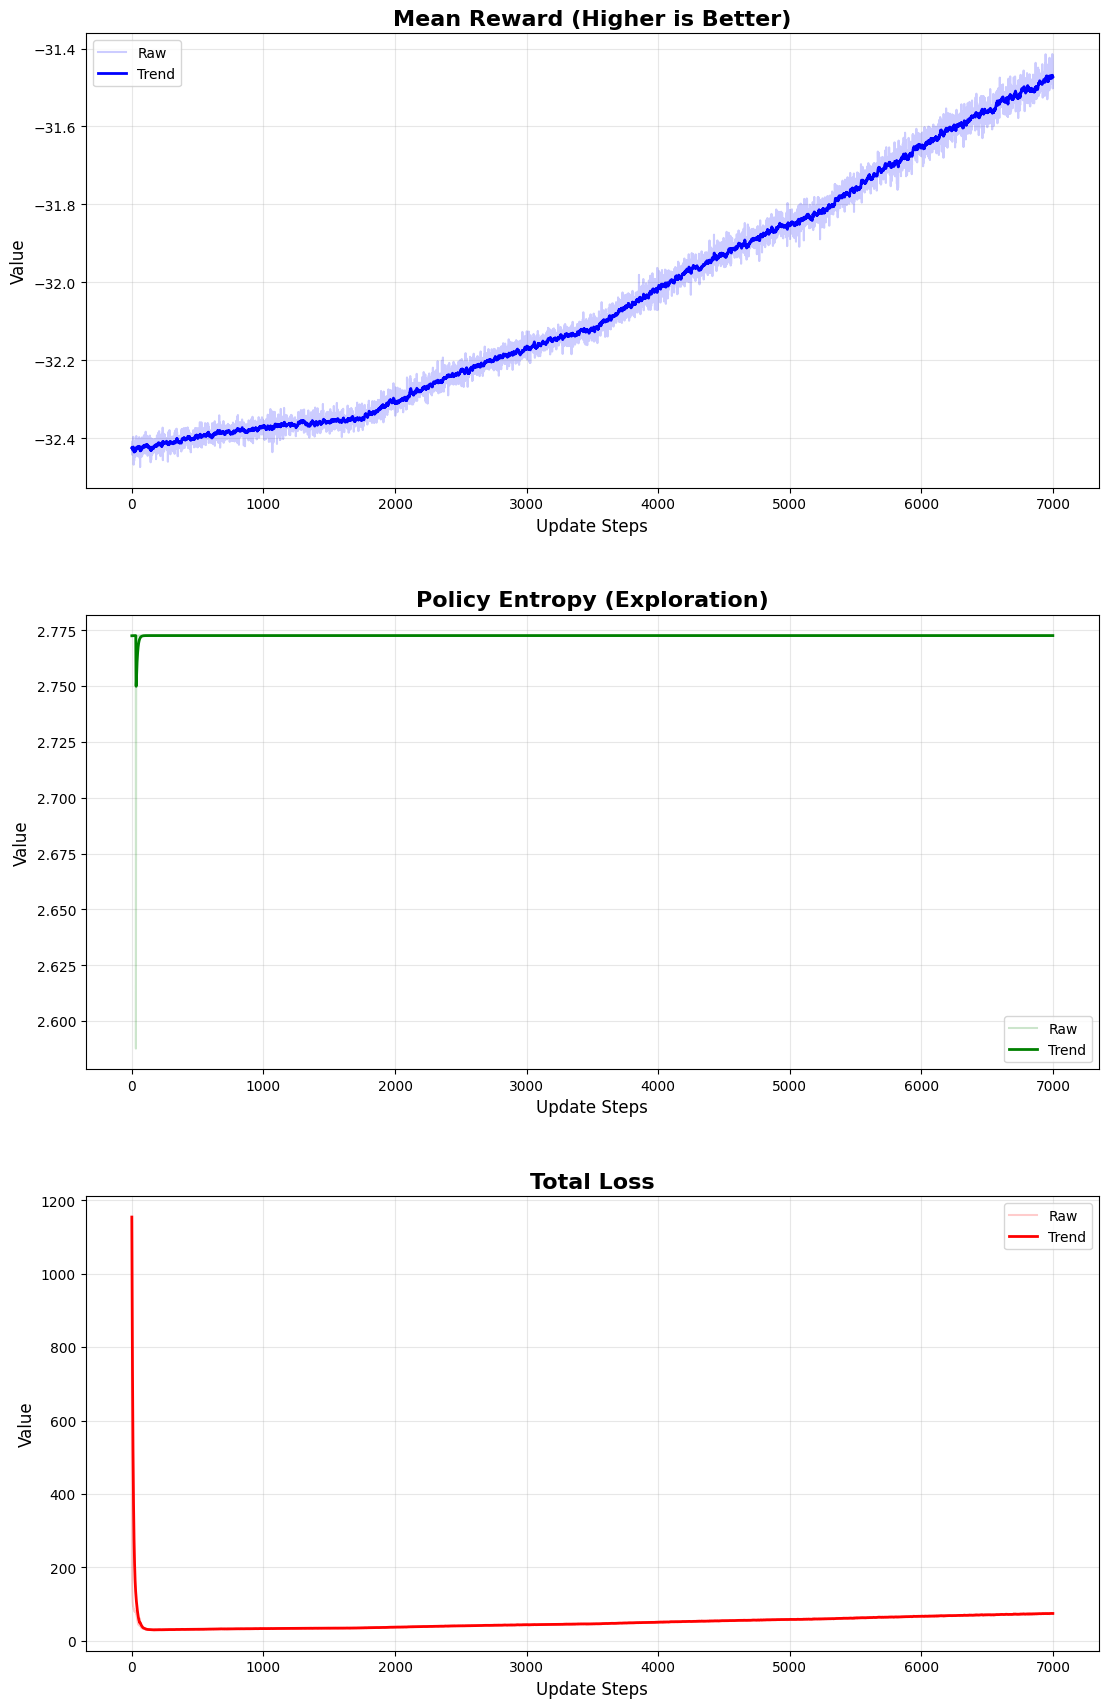

In [ ]:
# ==========================================
# 3. Robust & Clear Plotting
# ==========================================
def plot_training_results(history):
    # Standardize style
    plt.style.use('default')

    # Flatten the history arrays in case they are nested from chunking
    # This ensures we have a single continuous line per metric
    def flatten_metric(metric_data):
        arr = np.array(metric_data)
        return arr.reshape(-1) # Force to 1D array

    rewards = flatten_metric(history['reward'])
    entropies = flatten_metric(history['entropy'])
    losses = flatten_metric(history['loss'])

    # Simple EMA for the trendline
    def get_ema(data, alpha=0.9):
        smoothed = []
        curr = data[0]
        for val in data:
            curr = curr * alpha + val * (1 - alpha)
            smoothed.append(curr)
        return np.array(smoothed)

    fig, axs = plt.subplots(3, 1, figsize=(12, 18), dpi=100)

    metrics = [
        (rewards, 'Mean Reward (Higher is Better)', 'blue'),
        (entropies, 'Policy Entropy (Exploration)', 'green'),
        (losses, 'Total Loss', 'red')
    ]

    for i, (data, title, color) in enumerate(metrics):
        steps = np.arange(len(data))
        # Plot raw data with transparency
        axs[i].plot(steps, data, color=color, alpha=0.2, label='Raw')
        # Plot smoothed trendline
        axs[i].plot(steps, get_ema(data), color=color, linewidth=2, label='Trend')

        axs[i].set_title(title, fontsize=16, fontweight='bold')
        axs[i].set_xlabel('Update Steps', fontsize=12)
        axs[i].set_ylabel('Value', fontsize=12)
        axs[i].legend()
        axs[i].grid(True, alpha=0.3)

    plt.tight_layout(pad=4.0)
    plt.show()

# Run the plot
plot_training_results(history)

# Evaluation

In [ ]:
def get_top_k_trails(train_state, cipher: Cipher, k=5, num_eval_envs=1000):
    print(f"--- EVALUATING TOP {k} TRAILS: {cipher.name} ---")

    # Helper function to reconstruct the array into a clean hex string
    def format_hex(state_array):
        val = 0
        for i, chunk in enumerate(state_array):
            val |= (int(chunk) << (i * cipher.sbox_bits))
        hex_chars = cipher.state_size // 4
        return f"0x{val:0{hex_chars}X}"

    # 1. Prepare Batch of Environments
    rng = jax.random.PRNGKey(0)
    rngs = jax.random.split(rng, num_eval_envs)

    v_reset = jax.vmap(env_reset, in_axes=(None, 0, None))
    state = v_reset(cipher, rngs, 0.0)

    initial_starts = state.cipher_state
    total_crypto_probs = jnp.zeros(num_eval_envs)
    round_details = []

    # --- CHANGE 1: Update vmap to handle progress (None means scalar) ---
    v_obs = jax.vmap(get_observation, in_axes=(0, None))
    v_step = jax.vmap(env_step, in_axes=(None, 0, 0, None)) # added None for progress

    # Set evaluation progress to 1.0 (removes sparsity penalties)
    eval_progress = jnp.float32(1.0)

    # 2. Vectorized Rollout
    for r in range(cipher.n_rounds):
        input_diffs = state.cipher_state
        obs = v_obs(state, cipher)
        pi, _ = train_state.apply_fn(train_state.params, obs)

        # A. Masking
        in_nibbles = input_diffs
        current_round_mask = cipher.valid_mask[in_nibbles.astype(jnp.int32)]
        is_active_input = (in_nibbles > 0)[..., None]
        final_mask = jnp.where(is_active_input,
                               current_round_mask.at[:, :, 0].set(False),
                               current_round_mask)

        # B. Selection (Greedy for Evaluation)
        masked_logits = jnp.where(final_mask, pi.logits, -1e10)
        action = jnp.argmax(masked_logits, axis=-1)

        # C. Prob Calc
        round_log_probs = cipher.log_probs[in_nibbles.astype(jnp.int32), action.astype(jnp.int32)]
        active_sboxes = (in_nibbles > 0)
        pure_step_probs = jnp.sum(jnp.where(active_sboxes, round_log_probs, 0.0), axis=-1)
        total_crypto_probs += pure_step_probs

        # --- CHANGE 2: Pass eval_progress to the vectorized step ---
        state, _ = v_step(cipher, state, action, eval_progress)

        round_details.append({
            'in': input_diffs,
            'sbox_out': action,
            'p_layer': state.cipher_state,
            'step_prob': pure_step_probs,
            'done_at_step': state.done
        })

    # 3. Rank and Display Results (Rest of the function remains the same)
    is_alive = jnp.any(state.cipher_state > 0, axis=-1)
    filtered_probs = jnp.where(is_alive, total_crypto_probs, -1000.0)
    top_indices = jnp.argsort(filtered_probs)[::-1][:k]

    print("\n" + "="*20 + f" TOP {k} CRYPTO TRAILS " + "="*20)

    for i, idx in enumerate(top_indices):
        final_prob = filtered_probs[idx]
        if final_prob < -500: continue

        print(f"\n--- [Rank {i+1}] STARTING DIFFERENCE: {format_hex(initial_starts[idx])} ---")

        terminated_early = False
        for r_idx, detail in enumerate(round_details):
            print(f"Round {r_idx+1}:")
            print(f"  Input Diff:  {format_hex(detail['in'][idx])}")
            print(f"  S-Box Out:   {format_hex(detail['sbox_out'][idx])}")
            print(f"  P-Layer/Lin: {format_hex(detail['p_layer'][idx])}")
            print(f"  Round Prob:  2^{detail['step_prob'][idx]:.2f}")
            print("-" * 30)

            if detail['done_at_step'][idx] and r_idx < (cipher.n_rounds - 1):
                print(">>> TRAIL TERMINATED (Threshold or Vanishing)")
                terminated_early = True
                break

        if not terminated_early:
            print(">>> TRAIL STATUS: VALID (Completed all rounds)")

        print(f"\nFinal Trail Probability: 2^{final_prob:.2f}")

    print("\nEvaluation Complete.")

# MCTS Implementation

In [ ]:
import math
import numpy as np
import jax
import jax.numpy as jnp
import distrax
import time

class MCTSNode:
    def __init__(self, state, prior: float, action=None):
        self.state = state
        self.prior = prior
        self.action = action
        self.children = []
        self.visits = 0
        # In cryptanalysis, we track the MAX log prob found down this branch
        self.max_q = float(state.total_log_prob)
        self.is_expanded = False

def run_mcts_search(train_state, cipher, initial_state, num_simulations=2000, num_samples=32, c_puct=1.5):
    print(f"---  STARTING MCTS SEARCH: {num_simulations} Sims, {num_samples} Branches/Node ---")

    root = MCTSNode(initial_state, prior=1.0)
    rng = jax.random.PRNGKey(int(time.time()))

    # =======================================================
    # JAX COMPILED EXPANSION FUNCTION
    # Takes 1 state, asks the network for K actions, and steps the env K times
    # =======================================================
    @jax.jit
    def expand_node(state, key):
        # 1. Observation
        obs = get_observation(state, cipher)
        obs_batched = obs[None, ...]

        # 2. Inference
        pi, value = train_state.apply_fn(train_state.params, obs_batched)
        logits = pi.logits[0] # Shape: (num_sboxes, action_dim)
        val = value[0]

        # 3. Correct Masking for MCTS (Single State)
        in_nibbles = state.cipher_state
        # Indexing a 2D mask (size, size) with a 1D state (num_sboxes)
        # results in a 2D mask (num_sboxes, size)
        mask = cipher.valid_mask[in_nibbles.astype(jnp.int32)]

        # Identify active S-boxes to force non-zero transitions
        is_active = (in_nibbles > 0)[..., None]

        # Ensure that if an S-box is active (in_nibbles > 0), it cannot pick action 0
        mask = jnp.where(is_active, mask.at[:, 0].set(False), mask)

        # Apply mask to logits
        masked_logits = jnp.where(mask, logits, -1e10)

        # 4. Sample K independent actions
        dist = distrax.Categorical(logits=masked_logits)
        keys = jax.random.split(key, num_samples)
        actions = jax.vmap(dist.sample)(seed=keys)

        # 5. Calculate Priors (Sum log probs for the whole state)
        action_log_probs = jax.vmap(dist.log_prob)(actions)
        prior_probs = jnp.exp(jnp.sum(action_log_probs, axis=-1))

        # 6. Step Environment (Pass eval_progress = 1.0 to env_step)
        # Note: Added the 4th argument (1.0) to match your new env_step signature
        next_states, rewards = jax.vmap(env_step, in_axes=(None, None, 0, None))(
            cipher, state, actions, jnp.float32(1.0)
        )

        return actions, prior_probs, val, next_states

    # =======================================================
    # THE MCTS LOOP
    # =======================================================
    for sim in range(num_simulations):
        node = root
        search_path = [node]

        # --- STEP 1: SELECTION ---
        while node.is_expanded and not node.state.done:
            best_child = None
            best_score = -float('inf')

            # Normalize Q values for this node to [0, 1] so PUCT math works cleanly
            q_values = [c.max_q for c in node.children]
            min_q, max_q_val = min(q_values), max(q_values)

            for child in node.children:
                # Min-Max Normalization
                if max_q_val == min_q:
                    norm_q = 0.5
                else:
                    norm_q = (child.max_q - min_q) / (max_q_val - min_q + 1e-6)

                # PUCT Formula
                u_val = norm_q + c_puct * child.prior * math.sqrt(node.visits) / (1 + child.visits)

                if u_val > best_score:
                    best_score = u_val
                    best_child = child

            node = best_child
            search_path.append(node)

        # --- STEP 2: EXPANSION & EVALUATION ---
        if not node.state.done:
            rng, subkey = jax.random.split(rng)
            actions, priors, val, next_states = expand_node(node.state, subkey)

            # Convert to CPU numpy for python object iteration
            actions_np = np.array(actions)
            priors_np = np.array(priors)

            for i in range(num_samples):
                # Reconstruct the single JAX state from the batched outputs
                child_state = EnvState(
                    cipher_state=next_states.cipher_state[i],
                    round_count=next_states.round_count[i],
                    total_log_prob=next_states.total_log_prob[i],
                    done=next_states.done[i],
                    key=next_states.key[i],
                    is_started=next_states.is_started[i]
                )
                child_node = MCTSNode(child_state, prior=float(priors_np[i]), action=actions_np[i])
                node.children.append(child_node)

            node.is_expanded = True

        # --- STEP 3: BACKPROPAGATION (Max-Q) ---
        for path_node in reversed(search_path):
            path_node.visits += 1
            if path_node.is_expanded and path_node.children:
                path_node.max_q = max(c.max_q for c in path_node.children)

    # =======================================================
    # EXTRACT THE BEST FOUND PATH
    # =======================================================
    best_path = []
    current = root
    while current.children:
        # Always pick the child that lead to the highest total log prob
        best_child = max(current.children, key=lambda c: c.max_q)
        best_path.append(best_child)
        current = best_child

    return best_path

In [ ]:
def evaluate_with_mcts(train_state, cipher, target_rounds, starting_hex, num_sims=2000, branches=32):
    # Helper to print hex
    def format_hex(state_array):
        val = 0
        for i, chunk in enumerate(state_array):
            val |= (int(chunk) << (i * cipher.sbox_bits))
        hex_chars = cipher.state_size // 4
        return f"0x{val:0{hex_chars}X}"

    # 1. Create the cipher for the target rounds
    eval_cipher = cipher._replace(n_rounds=target_rounds)

    # 2. Build the Initial State from the hex integer
    temp_val = starting_hex
    initial_nibbles = []
    for _ in range(cipher.num_sboxes):
        mask = (1 << cipher.sbox_bits) - 1
        initial_nibbles.append(temp_val & mask)
        temp_val >>= cipher.sbox_bits

    start_array = jnp.array(initial_nibbles, dtype=jnp.uint32)

    initial_state = EnvState(
        cipher_state=start_array,
        round_count=jnp.int32(0),
        total_log_prob=jnp.float32(0.0),
        done=jnp.bool_(False),
        key=jax.random.PRNGKey(42),
        is_started=jnp.bool_(True)
    )

    # 3. RUN MCTS
    start_time = time.time()
    best_path_nodes = run_mcts_search(
        train_state,
        eval_cipher,
        initial_state,
        num_simulations=num_sims,
        num_samples=branches # How many paths the neural network suggests per node
    )
    print(f"MCTS Search Finished in {time.time() - start_time:.2f} seconds.\n")

    # 4. Print Results
    print("==================== MCTS BEST CRYPTO TRAIL ====================")
    print(f"--- STARTING DIFFERENCE: {format_hex(start_array)} ---")

    previous_state = start_array
    for r_idx, node in enumerate(best_path_nodes):
        action = node.action

        # Calculate exactly what this step's probability was
        step_log_probs = eval_cipher.log_probs[previous_state.astype(jnp.int32), action.astype(jnp.int32)]
        active_sboxes = (previous_state > 0)
        pure_step_prob = jnp.sum(jnp.where(active_sboxes, step_log_probs, 0.0), axis=-1)

        print(f"Round {r_idx+1}:")
        print(f"  Input Diff:  {format_hex(previous_state)}")
        print(f"  S-Box Out:   {format_hex(action)}")
        print(f"  P-Layer/Lin: {format_hex(node.state.cipher_state)}")
        print(f"  Round Prob:  2^{pure_step_prob:.2f}")
        print("-" * 30)

        previous_state = node.state.cipher_state

    last_node = best_path_nodes[-1]
    print("\n--- MCTS DEBUG INFO ---")
    print(f"Total Rounds Found: {len(best_path_nodes)}")
    print(f"Is Final Node 'Done'?: {last_node.state.done}")
    print(f"Final Node Round Count: {last_node.state.round_count}")
    print(f"Number of children for next round: {len(last_node.children)}")
    if len(last_node.children) == 0:
        print("REASON: MCTS found no valid moves to reach Round 4.")

    print(f">>> Final Trail Probability: 2^{best_path_nodes[-1].state.total_log_prob:.2f}")
    print(f">>> Final Active S-Boxes: {jnp.sum(best_path_nodes[-1].state.cipher_state > 0)}")


# Results

In [ ]:
for i in range(1,7):
  ROUNDS_TESTED = i
  eval_cipher = present_cipher_instance._replace(n_rounds=ROUNDS_TESTED)
  get_top_k_trails(
      final_train_state,
      eval_cipher,
      k=1,
      num_eval_envs=32768
  )

--- EVALUATING TOP 1 TRAILS: Present_64Bit ---

==================== TOP 1 CRYPTO TRAILS ====================

--- [Rank 1] STARTING DIFFERENCE: 0x0000000000000008 ---
Round 1:
  Input Diff:  0x0000000000000008
  S-Box Out:   0x000000000000000B
  P-Layer/Lin: 0x0001000000010001
  Round Prob:  2^-2.00
------------------------------
>>> TRAIL STATUS: VALID (Completed all rounds)

Final Trail Probability: 2^-2.00

Evaluation Complete.
--- EVALUATING TOP 1 TRAILS: Present_64Bit ---

==================== TOP 1 CRYPTO TRAILS ====================

--- [Rank 1] STARTING DIFFERENCE: 0x000000000000000F ---
Round 1:
  Input Diff:  0x000000000000000F
  S-Box Out:   0x0000000000000004
  P-Layer/Lin: 0x0000000100000000
  Round Prob:  2^-2.00
------------------------------
Round 2:
  Input Diff:  0x0000000100000000
  S-Box Out:   0x0000000900000000
  P-Layer/Lin: 0x0100000000000100
  Round Prob:  2^-2.00
------------------------------
>>> TRAIL STATUS: VALID (Completed all rounds)

Final Trail Probab

# results with guided search

In [ ]:
import jax
import jax.numpy as jnp

def print_trail(trail_results):
    """
    Formates and prints the cryptographic trail found by the search.
    """
    print("\n" + "="*20 + " VALUE-GUIDED CRYPTO TRAIL " + "="*20)
    total_prob = 0.0

    for entry in trail_results:
        # Convert JAX arrays to standard Python integers for hex formatting
        in_diff = "".join([f"{int(x):x}" for x in entry['in']])
        out_diff = "".join([f"{int(x):x}" for x in entry['out']])
        prob = float(entry['prob'])
        total_prob += prob

        print(f"Round {entry['round']}:")
        print(f"  Input Diff:  0x{in_diff}")
        print(f"  S-Box Out:   0x{out_diff}")
        print(f"  Round Prob:  2^{prob:.2f}")
        print("-" * 30)

    print(f">>> Final Trail Probability: 2^{total_prob:.2f}")

    # Calculate active S-boxes based on the last round's output
    # (Assuming we want to see how sparse the final round was)
    last_active = jnp.sum(trail_results[-1]['out'] > 0)
    print(f">>> Final Active S-Boxes: {last_active}")
    print("="*67 + "\n")

import jax
import jax.numpy as jnp
import jax.tree  # Use the modern jax.tree module

def evaluate_value_guided_search(train_state, cipher, target_rounds=7, starting_hex=None):
    rng = jax.random.PRNGKey(42)

    # 1. Initialize State
    if starting_hex is not None:
        initial_val = jnp.array([(starting_hex >> (4*i)) & 0xF for i in range(16)][::-1], dtype=jnp.uint32)
        current_state = EnvState(
            cipher_state=initial_val, round_count=jnp.int32(0),
            total_log_prob=jnp.float32(0.0), done=jnp.bool_(False),
            key=rng, is_started=jnp.bool_(True)
        )
    else:
        current_state = env_reset(cipher, rng, progress=1.0)

    full_trail = []
    print(f"--- STARTING VALUE-GUIDED SEARCH ({target_rounds} Rounds) ---")

    for r in range(target_rounds):
        # 2. Get Actor Logits for current state
        obs = get_observation(current_state, cipher)
        # Add a batch dimension for the network [1, obs_dim]
        pi, _ = train_state.apply_fn(train_state.params, obs[None, :])

        # 3. Masking (Force non-zero transitions for active S-boxes)
        in_nibbles = current_state.cipher_state
        mask = cipher.valid_mask[in_nibbles.astype(jnp.int32)]
        is_active = (in_nibbles > 0)[..., None]
        final_mask = jnp.where(is_active, mask.at[:, 0].set(False), mask)

        # 4. Generate 256 Candidates
        rng, _rng = jax.random.split(rng)
        # pi.logits[0] removes the batch dimension added in step 2
        masked_logits = get_masked_logits(pi.logits[0], final_mask)
        candidate_actions = distrax.Categorical(logits=masked_logits).sample(seed=_rng, sample_shape=(256,))

        # 5. VECTORIZED EVALUATION
        # FIX: Changed jax.tree_map to jax.tree.map
        batched_states = jax.tree.map(lambda x: jnp.broadcast_to(x, (256,) + x.shape), current_state)

        # Step all 256 candidates at once
        next_states, rewards = jax.vmap(env_step, in_axes=(None, 0, 0, None))(
            cipher, batched_states, candidate_actions, jnp.float32(1.0)
        )

        # Get observations and Values for all next states
        next_obs = jax.vmap(get_observation, in_axes=(0, None))(next_states, cipher)
        _, values = train_state.apply_fn(train_state.params, next_obs)

        # Total Score = Immediate Reward + Future Value (Critic Prediction)
        # values often comes out as (256, 1), squeeze it to (256,) to match rewards
        scores = jnp.squeeze(values) + rewards

        # 6. Selection
        best_idx = jnp.argmax(scores)
        best_action = candidate_actions[best_idx]

        # Calculate true differential probability for this step
        round_prob = jnp.sum(cipher.log_probs[in_nibbles.astype(jnp.int32), best_action.astype(jnp.int32)] * (in_nibbles > 0))

        full_trail.append({
            "round": r + 1,
            "in": current_state.cipher_state,
            "out": best_action,
            "prob": round_prob
        })

        # Step the real environment to get the actual next state for the loop
        current_state, _ = env_step(cipher, current_state, best_action, jnp.float32(1.0))
        if current_state.done: break

    print_trail(full_trail)
    return full_trail

In [ ]:
# 1. Run the search
trail = evaluate_value_guided_search(
    train_state=final_train_state,
    cipher=skinny_cipher_instance,
    target_rounds=7,
    starting_hex=0x0002000000002000   # Your successful starting point
)


--- STARTING VALUE-GUIDED SEARCH (7 Rounds) ---

==================== VALUE-GUIDED CRYPTO TRAIL ====================
Round 1:
  Input Diff:  0x0002000000002000
  S-Box Out:   0x0006000000001000
  Round Prob:  2^-4.00
------------------------------
Round 2:
  Input Diff:  0x0007000600000006
  S-Box Out:   0x000b00080000000e
  Round Prob:  2^-9.00
------------------------------
Round 3:
  Input Diff:  0x00eb000b8000000b
  S-Box Out:   0x0033000ce000000f
  Round Prob:  2^-14.00
------------------------------
Round 4:
  Input Diff:  0x00230033c0e000d3
  S-Box Out:   0x003b009e20e0007a
  Round Prob:  2^-22.00
------------------------------
Round 5:
  Input Diff:  0xe7bb003b0029e01b
  S-Box Out:   0x97fd00af005fd0bd
  Round Prob:  2^-31.00
------------------------------
Round 6:
  Input Diff:  0xc32097fdaf0ac8fd
  S-Box Out:   0x7a30e187580bef46
  Round Prob:  2^-40.00
------------------------------
>>> Final Trail Probability: 2^-120.00
>>> Final Active S-Boxes: 14



# Results MCTS

In [ ]:
# ==========================================
# EXECUTE MCTS ON SKINNY-64 FOR 6 ROUNDS
# ==========================================
# We use the 1-nibble start you found previously
evaluate_with_mcts(
    train_state=final_train_state, # Pass your trained agent
    cipher=skinny_cipher_instance,     # Will work for AES or PRESENT too!
    target_rounds=6,
    starting_hex=0x0000000020000000,
    num_sims=1000,                     # Increase to 5000+ for deeper ciphers
    branches=256                        # 32 is a great balance of width vs speed
)

# evaluare diferenta specifica de intrare

In [ ]:
import jax
import jax.numpy as jnp

def evaluate_parallel_specific_start(train_state, cipher, starting_hex, num_envs=8192, n_rounds=14):
    key = jax.random.PRNGKey(42)

    # 1. Manual Hex-to-Nibble Decomposition (Python handles the large int)
    temp_val = starting_hex
    initial_nibbles = []
    for _ in range(16): # PRESENT has 16 S-boxes
        initial_nibbles.append(temp_val & 0xF)
        temp_val >>= 4

    # Broadcast to (num_envs, 16)
    in_nibbles = jnp.tile(jnp.array(initial_nibbles, dtype=jnp.uint32), (num_envs, 1))
    total_log_probs = jnp.zeros(num_envs)

    # Pre-calculate bit indices for the manual P-layer to speed up vmap
    # bit_indices shape: (64, 2) -> which nibble and which bit inside that nibble
    bit_positions = jnp.array([[n, b] for n in range(16) for b in range(4)], dtype=jnp.uint32)

    def manual_p_layer_vmap(sbox_out_nibbles):
        # Flatten 16 nibbles into 64 bits
        # bits[i] = (nibble >> bit_in_nibble) & 1
        flat_bits = (sbox_out_nibbles[bit_positions[:, 0]] >> bit_positions[:, 1]) & 1
        # Apply the cipher's p_map (the permutation)
        permuted_bits = flat_bits[cipher.p_map]
        # Re-pack 64 bits back into 16 nibbles
        new_nibbles = jnp.zeros(16, dtype=jnp.uint32)
        for b in range(4):
            # Each nibble n gets bits at indices 4*n + b
            new_nibbles = new_nibbles | (permuted_bits[jnp.arange(16)*4 + b] << b)
        return new_nibbles

    print(f"--- PARALLEL STOCHASTIC SEARCH ({num_envs} Envs) ---")
    print(f"Start: {hex(starting_hex)} | Rounds: {n_rounds}")

    for r in range(n_rounds):
        # A. Observation (Vmapped)
        # Note: If your get_observation requires an EnvState object,
        # we pass a 'dummy' state using the current nibble vector
        obs = jax.vmap(lambda n: get_observation(
            EnvState(
                cipher_state=n,
                round_count=jnp.array(r, dtype=jnp.int32),
                total_log_prob=jnp.array(0.0, dtype=jnp.float32),
                done=jnp.array(False, dtype=jnp.bool_),
                key=jax.random.PRNGKey(0),
                is_started=jnp.array(True, dtype=jnp.bool_)
            ), cipher))(in_nibbles)

        # B. Inference
        pi, _ = train_state.apply_fn(train_state.params, obs)
        logits = pi.logits

        # C. Validity Masking
        current_masks = cipher.valid_mask[in_nibbles.astype(jnp.int32)]
        is_active = (in_nibbles > 0)[:, :, None]
        active_only = current_masks.at[:, :, 0].set(False)
        final_masks = jnp.where(is_active, active_only, current_masks)

        # D. Stochastic Sampling (The key to finding the 2^-61 trail)
        masked_logits = jnp.where(final_masks, logits, -1e10)
        key, subkey = jax.random.split(key)
        # Sample actions across the batch
        actions = jax.random.categorical(subkey, masked_logits, axis=-1)

        # E. Update Probability
        step_log_probs = cipher.log_probs[in_nibbles.astype(jnp.int32), actions.astype(jnp.int32)]
        total_log_probs += jnp.sum(jnp.where(in_nibbles > 0, step_log_probs, 0.0), axis=-1)

        # F. P-Layer Transition (Vmapped manual logic)
        in_nibbles = jax.vmap(manual_p_layer_vmap)(actions)

    # Find the best result
    best_idx = jnp.argmax(total_log_probs)
    best_prob = total_log_probs[best_idx]

    print("=" * 50)
    print(f"RESULTS ACROSS {num_envs} PATHS:")
    print(f"Worst Path:  2^{float(jnp.min(total_log_probs)):.2f}")
    print(f"Mean Path:   2^{float(jnp.mean(total_log_probs)):.2f}")
    print(f"BEST TRAIL:  2^{float(best_prob):.2f}")
    print("=" * 50)

    return best_prob

# --- EXECUTION ---
# Using 8192 environments to give the agent thousands of chances to find the sparse path
best_result = evaluate_parallel_specific_start(
    train_state=final_train_state,
    cipher=present_cipher_instance,
    starting_hex=0x0000000000000007,
    num_envs=16384,
    n_rounds=9
)

NameError: name 'final_train_state' is not defined

# Load model from checkpoint and test

In [ ]:
def load_and_evaluate(cipher, checkpoint_path, num_eval=16384):
    # 1. Reconstruct the EXACT same network architecture used in training
    network = AttentionUniversalActorCritic(
        num_sboxes=cipher.num_sboxes,
        sbox_bits=cipher.sbox_bits,
        action_dim=2**cipher.sbox_bits,
        d_model=32,          # Must match your training d_model
        num_tf_blocks=2       # Must match your training blocks
    )

    # 2. Initialize Orbax checkpointer
    checkpointer = ocp.PyTreeCheckpointer()

    # 3. Create dummy data to define the 'shape' of the parameters
    init_rng = jax.random.PRNGKey(0)
    temp_env = env_reset(cipher, init_rng)
    temp_obs = get_observation(temp_env, cipher)
    init_x = jnp.zeros((1, temp_obs.shape[-1]))

    # JAX helper to get parameter shapes without actual initialization
    abstract_params = jax.eval_shape(lambda: network.init(init_rng, init_x))

    # 4. Restore the parameters from the checkpoint path
    print(f"Loading model weights from: {checkpoint_path}")
    restored_params = checkpointer.restore(checkpoint_path, item=abstract_params)

    # 5. Create a dummy TrainState (only needed because get_top_k_trails expects it)
    eval_state = TrainState.create(
        apply_fn=network.apply,
        params=restored_params,
        tx=optax.adam(1e-3) # Optimizer doesn't matter for evaluation
    )

    # 6. Run the evaluation
    get_top_k_trails(
        eval_state,
        cipher,
        k=1,
        num_eval_envs=num_eval
    )

# --- EXECUTION ---
# Point this to the specific chunk folder in your Google Drive
path = "/content/checkpointsPRESENTannealing/chunk_5"

if os.path.exists(path):
    load_and_evaluate(present_cipher_instance, path)
else:
    print("Checkpoint path not found! Check your Drive folders.")

Loading model weights from: /content/checkpointsPRESENTannealing/chunk_5
--- EVALUATING TOP 1 TRAILS: Present_64Bit ---

==================== TOP 1 CRYPTO TRAILS ====================

--- [Rank 1] STARTING DIFFERENCE: 0x000000000000000F ---
Round 1:
  Input Diff:  0x000000000000000F
  S-Box Out:   0x0000000000000001
  P-Layer/Lin: 0x0000000000000001
  Round Prob:  2^-2.00
------------------------------
Round 2:
  Input Diff:  0x0000000000000001
  S-Box Out:   0x0000000000000003
  P-Layer/Lin: 0x0000000000010001
  Round Prob:  2^-2.00
------------------------------
Round 3:
  Input Diff:  0x0000000000010001
  S-Box Out:   0x0000000000090003
  P-Layer/Lin: 0x0010000000010011
  Round Prob:  2^-4.00
------------------------------
Round 4:
  Input Diff:  0x0010000000010011
  S-Box Out:   0x0090000000090033
  P-Layer/Lin: 0x2010000000032013
  Round Prob:  2^-8.00
------------------------------
Round 5:
  Input Diff:  0x2010000000032013
  S-Box Out:   0xE09000000004A07B
  P-Layer/Lin: 0xA0098

# Fine tune trained model

In [ ]:
import orbax.checkpoint as ocp
import os

def resume_training(cipher: Cipher, config: TrainConfig, checkpoint_path: str):
    # 1. Re-initialize the network and state (same architecture!)
    network = AttentionUniversalActorCritic(
        num_sboxes=cipher.num_sboxes,
        sbox_bits=cipher.sbox_bits,
        action_dim=2**cipher.sbox_bits,
        d_model=128,
        num_tf_blocks=3
    )

    # 2. Setup Checkpointer
    checkpointer = ocp.PyTreeCheckpointer()

    # 3. Dummy init to get the structure
    init_rng = jax.random.PRNGKey(0)
    temp_env = env_reset(cipher, init_rng)
    temp_obs = get_observation(temp_env, cipher)
    init_x = jnp.zeros((1, temp_obs.shape[-1]))
    abstract_params = jax.eval_shape(lambda: network.init(init_rng, init_x))

    # 4. LOAD THE SAVED PARAMS
    print(f"Loading weights from: {checkpoint_path}")
    restored_params = checkpointer.restore(checkpoint_path, item=abstract_params)

    # 5. Create a new TrainState with the restored params
    # Tip: You can change the learning rate here if you want to fine-tune
    new_train_state = TrainState.create(
        apply_fn=network.apply,
        params=restored_params,
        tx=optax.adam(learning_rate=config.lr * 0.5) # Lower LR for fine-tuning
    )

    # 6. Call train again, but you'll need a modified train function
    # that accepts an 'initial_state' instead of creating a new one.
    # For now, you can just manually run a few more chunks.
    return new_train_state

# --- Example Usage ---
# path = "/content/drive/MyDrive/checkpoints_aes/chunk_20"
# fine_tuned_state = resume_training(aes_cipher_instance, A100_FAST, path)

# fine tuning pe aes sa invete cu un singur sbox

In [ ]:
import jax
import jax.numpy as jnp
import optax
import distrax
import orbax.checkpoint as ocp
import os
import time

# ==========================================
# 1. THE FINE-TUNING CONFIG
# ==========================================
class TrainConfig:
    def __init__(self, **kwargs):
        for k, v in kwargs.items():
            setattr(self, k, v)

FINE_TUNE_FAST = TrainConfig(
    num_envs=16384,
    num_minibatches=8,       # Fixed to 8 to match your 2048 internal batch size
    update_epochs=2,
    total_updates=5000,
    lr=5e-5,
    ent_coef=0.05,
    clip_eps=0.1,
    gamma=0.999,
    gae_lambda=0.95
)

# ==========================================
# 2. THE FINETUNE LOOP (Wraps your exact code)
# ==========================================
def finetune(cipher, config, checkpoint_path):
    print(f"Loading weights from {checkpoint_path}...")

    # Setup & Hardware
    num_envs = config.num_envs
    num_minibatches = config.num_minibatches
    update_epochs = config.update_epochs
    total_updates = config.total_updates
    clip_eps = config.clip_eps
    gamma = config.gamma
    gae_lambda = config.gae_lambda
    num_steps = cipher.n_rounds
    rng = jax.random.PRNGKey(42)

    # --- NETWORK INITIALIZATION ---
    network = AttentionUniversalActorCritic(
        num_sboxes=cipher.num_sboxes,
        sbox_bits=cipher.sbox_bits,
        action_dim=2**cipher.sbox_bits,
        d_model=64,
        num_tf_blocks=3
    )

    # --- ORBAX CHECKPOINT LOADING (The Magic Step) ---
    checkpointer = ocp.PyTreeCheckpointer()
    loaded_params = checkpointer.restore(checkpoint_path)
    print("✅ Weights successfully loaded into memory!")

    # Create the TrainState using the loaded weights and the gentle fine-tuning LR
    train_state = TrainState.create(
        apply_fn=network.apply,
        params=loaded_params,
        tx=optax.adam(learning_rate=config.lr)
    )

    # --- ADVANTAGE ESTIMATION (Your exact code) ---
    def calculate_gae(trajectory, last_val):
        def _gae_step(gae_and_next_val, step_data):
            gae, next_val = gae_and_next_val
            reward, value, done = step_data
            delta = reward + gamma * next_val * (1 - done) - value
            gae = delta + gamma * gae_lambda * (1 - done) * gae
            return (gae, value), gae

        initial_gae = jnp.zeros_like(last_val)
        _, advantages = jax.lax.scan(_gae_step, (initial_gae, last_val), (trajectory.reward, trajectory.value, trajectory.done), reverse=True)
        return advantages, advantages + trajectory.value

    # --- PPO LOSS (Your exact code) ---
    def ppo_loss_fn(params, traj_batch, advantages, targets):
        pi, values = network.apply(params, traj_batch.obs)
        log_prob_sum = jnp.sum(pi.log_prob(traj_batch.action), axis=-1)
        old_log_prob_sum = jnp.sum(traj_batch.log_prob, axis=-1)
        ratio = jnp.exp(log_prob_sum - old_log_prob_sum)
        surr1 = ratio * advantages
        surr2 = jnp.clip(ratio, 1.0 - clip_eps, 1.0 + clip_eps) * advantages
        pi_loss = -jnp.mean(jnp.minimum(surr1, surr2))
        v_loss = 0.5 * jnp.mean(jnp.square(targets - values))
        ent = jnp.mean(pi.entropy())
        return pi_loss + 0.5 * v_loss - config.ent_coef * ent

    selection_mask = jnp.full((num_envs, cipher.num_sboxes, 2**cipher.sbox_bits), True, dtype=jnp.bool_)
    selection_mask = selection_mask.at[:, :, 0].set(False)

    # --- TRAINING ITERATION (Your exact code) ---
    def train_iteration(runner_state, update_idx):
        train_state, env_state, last_obs, rng = runner_state

        def rollout_step(carry, _):
            train_state, env_state, last_obs, rng = carry
            rng, _rng = jax.random.split(rng)
            pi, value = network.apply(train_state.params, last_obs)
            is_selection_step = jnp.logical_not(env_state.is_started)
            in_nibbles = env_state.cipher_state

            round_mask = cipher.valid_mask[in_nibbles.astype(jnp.int32)]
            final_mask = jnp.where(is_selection_step[:, None, None], selection_mask, round_mask)

            masked_logits = get_masked_logits(pi.logits, final_mask)
            pi_masked = distrax.Categorical(logits=masked_logits)
            action = pi_masked.sample(seed=_rng)
            log_prob = pi_masked.log_prob(action)
            next_env_state, reward = jax.vmap(env_step, in_axes=(None, 0, 0))(cipher, env_state, action)
            next_obs = jax.vmap(get_observation, in_axes=(0, None))(next_env_state, cipher)
            transition = Transition(obs=last_obs, action=action, reward=reward, value=value, log_prob=log_prob, done=next_env_state.done)
            return (train_state, next_env_state, next_obs, rng), transition

        runner_state, traj_batch = jax.lax.scan(rollout_step, (train_state, env_state, last_obs, rng), None, length=num_steps)
        train_state, env_state, last_obs, rng = runner_state
        _, last_val = network.apply(train_state.params, last_obs)
        advantages, targets = calculate_gae(traj_batch, last_val)

        flat_traj_batch = jax.tree.map(lambda x: x.reshape((-1,) + x.shape[2:]), traj_batch)
        flat_advantages = advantages.reshape(-1)
        flat_targets = targets.reshape(-1)
        flat_advantages = (flat_advantages - flat_advantages.mean()) / (flat_advantages.std() + 1e-8)
        batch_size = num_envs * num_steps
        m_size = batch_size // num_minibatches

        def update_epoch(carry, _):
            train_state, key = carry
            key, _key = jax.random.split(key)
            permutation = jax.random.permutation(_key, batch_size)
            shuffled_traj = jax.tree.map(lambda x: x[permutation], flat_traj_batch)
            shuffled_adv = flat_advantages[permutation]
            shuffled_tar = flat_targets[permutation]

            def update_minibatch(s, m_idx):
                start = m_idx * m_size
                t_slice = jax.tree.map(lambda x: jax.lax.dynamic_slice_in_dim(x, start, m_size), shuffled_traj)
                a_slice = jax.lax.dynamic_slice_in_dim(shuffled_adv, start, m_size)
                v_slice = jax.lax.dynamic_slice_in_dim(shuffled_tar, start, m_size)
                grad_fn = jax.value_and_grad(ppo_loss_fn)
                loss, grads = grad_fn(s.params, t_slice, a_slice, v_slice)
                return s.apply_gradients(grads=grads), loss

            train_state, mb_losses = jax.lax.scan(update_minibatch, train_state, jnp.arange(num_minibatches))
            return (train_state, key), jnp.mean(mb_losses)

        (train_state, rng), epoch_losses = jax.lax.scan(update_epoch, (train_state, rng), jnp.arange(update_epochs))
        progress = update_idx.astype(jnp.float32) / total_updates
        rng, _rng = jax.random.split(rng)
        reset_rngs = jax.random.split(_rng, num_envs)
        env_state = jax.vmap(env_reset, in_axes=(None, 0, None))(cipher, reset_rngs, progress)
        last_obs = jax.vmap(get_observation, in_axes=(0, None))(env_state, cipher)
        flat_obs_for_ent = traj_batch.obs.reshape(-1, traj_batch.obs.shape[-1])
        pi_final, _ = network.apply(train_state.params, flat_obs_for_ent)

        metrics = {"reward": jnp.mean(traj_batch.reward), "entropy": jnp.mean(pi_final.entropy()), "loss": jnp.mean(epoch_losses)}
        return (train_state, env_state, last_obs, rng), metrics

    @jax.jit
    def run_chunk(r_state, u_indices):
        return jax.lax.scan(train_iteration, r_state, u_indices)

    # --- START EXECUTION ---
    print("\nStarting Fine-Tuning Phase (Targeting 1 -> 4 -> 16 -> 4 Trail)...")
    print("-" * 60)

    init_reset_rng = jax.random.split(rng, num_envs)
    env_state = jax.vmap(env_reset, in_axes=(None, 0, None))(cipher, init_reset_rng, 0.0)
    obs = jax.vmap(get_observation, in_axes=(0, None))(env_state, cipher)

    save_dir = '/content/drive/MyDrive/checkpoints_AES_finetuned'
    os.makedirs(save_dir, exist_ok=True)
    ft_checkpointer = ocp.PyTreeCheckpointer()

    chunk_size = 500  # Prints out 10 chunks total
    num_chunks = total_updates // chunk_size
    current_runner_state = (train_state, env_state, obs, rng)

    for i in range(num_chunks):
        start_t = time.time()
        update_indices = jnp.arange(i * chunk_size, (i + 1) * chunk_size)
        current_runner_state, chunk_metrics = run_chunk(current_runner_state, update_indices)

        c_reward = float(jnp.mean(chunk_metrics["reward"]))
        c_entropy = float(jnp.mean(chunk_metrics["entropy"]))
        print(f"Chunk {i+1}/{num_chunks} | Reward: {c_reward:.2f} | Entropy: {c_entropy:.4f} | Time: {time.time()-start_t:.1f}s")

        if (i + 1) % 5 == 0 or (i + 1) == num_chunks:
            chunk_path = os.path.join(save_dir, f'chunk_{i+1}')
            ft_checkpointer.save(chunk_path, current_runner_state[0].params, force=True)

    print("========================================")
    print("Fine-tuning complete!")
    return current_runner_state[0]


# ==========================================
# 3. TRIGGER THE RUN AND EVALUATE
# ==========================================
checkpoint_to_load = '/content/drive/MyDrive/checkpoints_AES/chunk_20'

# Execute the fine-tuning!
final_finetuned_state = finetune(aes_cipher_instance, FINE_TUNE_FAST, checkpoint_to_load)

# Automatically evaluate when finished
ROUNDS_TESTED = 4
eval_cipher = aes_cipher_instance._replace(n_rounds=ROUNDS_TESTED)

get_top_k_trails(final_finetuned_state, eval_cipher, k=1, num_eval_envs=16384)

Loading weights from /content/drive/MyDrive/checkpoints_AES/chunk_20...
✅ Weights successfully loaded into memory!

Starting Fine-Tuning Phase (Targeting 1 -> 4 -> 16 -> 4 Trail)...
------------------------------------------------------------
Chunk 1/10 | Reward: -76.59 | Entropy: 2.4944 | Time: 171.2s
Chunk 2/10 | Reward: -76.98 | Entropy: 2.6528 | Time: 152.8s
Chunk 3/10 | Reward: -77.23 | Entropy: 2.7458 | Time: 108.8s
Chunk 4/10 | Reward: -77.50 | Entropy: 2.8902 | Time: 108.8s
Chunk 5/10 | Reward: -77.72 | Entropy: 2.9861 | Time: 108.8s
Chunk 6/10 | Reward: -77.83 | Entropy: 2.9977 | Time: 108.8s
Chunk 7/10 | Reward: -77.86 | Entropy: 3.0065 | Time: 108.8s
Chunk 8/10 | Reward: -77.87 | Entropy: 3.0095 | Time: 108.8s
Chunk 9/10 | Reward: -77.79 | Entropy: 3.0158 | Time: 108.8s
Chunk 10/10 | Reward: -77.72 | Entropy: 3.0178 | Time: 108.8s
Fine-tuning complete!
--- EVALUATING TOP 1 TRAILS: AES_128Bit ---

==================== TOP 1 CRYPTO TRAILS ====================

--- [Rank 1] STA

In [ ]:
get_top_k_trails(
    final_finetuned_state,
    eval_cipher,
    k=5,
    num_eval_envs=131072  # CRANK THIS UP
)

--- EVALUATING TOP 5 TRAILS: AES_128Bit ---

==================== TOP 5 CRYPTO TRAILS ====================

--- [Rank 1] STARTING DIFFERENCE: 0x0000005D00000000003C000000000000 ---
Round 1:
  Input Diff:  0x0000005D00000000003C000000000000
  S-Box Out:   0x0000000600000000000A000000000000
  P-Layer/Lin: 0x00000600000000000000120000001800
  Round Prob:  2^-14.00
------------------------------
Round 2:
  Input Diff:  0x00000600000000000000120000001800
  S-Box Out:   0x0000DA00000000000000A9000000E400
  P-Layer/Lin: 0x00AF37A90075E4A900DAE44900DAD3E0
  Round Prob:  2^-21.00
------------------------------
Round 3:
  Input Diff:  0x00AF37A90075E4A900DAE44900DAD3E0
  S-Box Out:   0x007EC6D700F4FE4300184CDA004D7A37
  P-Layer/Lin: 0xD80323E1BF9A0088C84E9DA8F51F0B4E
  Round Prob:  2^-84.00
------------------------------
Round 4:
  Input Diff:  0xD80323E1BF9A0088C84E9DA8F51F0B4E
  S-Box Out:   0xD67EEF144EF400B14FA24C4C3F4DB1B2
  P-Layer/Lin: 0xF1EC0CC2F151B36CD9F428FBD415DE89
  Round Prob:  2^-

In [ ]:
def get_top_k_trails_sniper(train_state, cipher: Cipher, k=1, num_eval_envs=131072):
    print(f"--- 🎯 SNIPER EVALUATION: {num_eval_envs} Environments (1-Byte Start) ---")

    def format_hex(state_array):
        val = 0
        for i, chunk in enumerate(state_array):
            val |= (int(chunk) << (i * cipher.sbox_bits))
        hex_chars = cipher.state_size // 4
        return f"0x{val:0{hex_chars}X}"

    # 1. Prepare Batch of Environments: FORCE 1-BYTE START
    rng = jax.random.PRNGKey(int(time.time()))
    rngs = jax.random.split(rng, num_eval_envs)

    @jax.jit
    def sniper_reset(key):
        k1, k2, k3 = jax.random.split(key, 3)
        idx = jax.random.randint(k1, (), 0, cipher.num_sboxes)
        val = jax.random.randint(k2, (), 1, 2**cipher.sbox_bits)
        starting_state = jnp.zeros((cipher.num_sboxes,), dtype=jnp.uint32)
        starting_state = starting_state.at[idx].set(val.astype(jnp.uint32))
        return EnvState(
            cipher_state=starting_state, round_count=0,
            total_log_prob=0.0, done=False, key=k3, is_started=True
        )

    state = jax.vmap(sniper_reset)(rngs)
    initial_starts = state.cipher_state
    total_crypto_probs = jnp.zeros(num_eval_envs)
    round_details = []

    v_obs = jax.vmap(get_observation, in_axes=(0, None))
    v_step = jax.vmap(env_step, in_axes=(None, 0, 0))

    # 2. Vectorized Rollout
    for r in range(cipher.n_rounds):
        input_diffs = state.cipher_state
        obs = v_obs(state, cipher)
        pi, _ = train_state.apply_fn(train_state.params, obs)

        # Masking
        in_nibbles = input_diffs
        current_round_mask = cipher.valid_mask[in_nibbles.astype(jnp.int32)]
        is_active_input = (in_nibbles > 0)[..., None]
        final_mask = jnp.where(is_active_input,
                               current_round_mask.at[:, :, 0].set(False),
                               current_round_mask)

        # 🎯 STOCHASTIC SELECTION (Essential for searching 100k paths)
        masked_logits = jnp.where(final_mask, pi.logits, -1e10)
        rng, _rng = jax.random.split(rng)
        # We sample instead of argmax to explore the agent's uncertainty
        action = distrax.Categorical(logits=masked_logits).sample(seed=_rng)

        # Prob Calc
        round_log_probs = cipher.log_probs[in_nibbles.astype(jnp.int32), action.astype(jnp.int32)]
        active_sboxes = (in_nibbles > 0)
        pure_step_probs = jnp.sum(jnp.where(active_sboxes, round_log_probs, 0.0), axis=-1)
        total_crypto_probs += pure_step_probs

        # Step Environment
        state, _ = v_step(cipher, state, action)

        round_details.append({
            'in': input_diffs, 'sbox_out': action,
            'p_layer': state.cipher_state, 'step_prob': pure_step_probs,
            'done_at_step': state.done
        })

    # 3. Rank and Display
    is_alive = jnp.any(state.cipher_state > 0, axis=-1)
    # Give a massive bonus to trails that compressed in the final round (sparsity reward)
    final_active_count = jnp.sum(state.cipher_state > 0, axis=-1)
    fitness = total_crypto_probs - (final_active_count * 2.0)

    filtered_fitness = jnp.where(is_alive, fitness, -1000.0)
    top_indices = jnp.argsort(filtered_fitness)[::-1][:k]

    # # --- EXTREME RANKING ---
    # # Only consider it a 'Success' if final active <= 4
    # is_success = jnp.logical_and(is_alive, final_active_count <= 4)

    # # If no one succeeded, rank by lowest active count
    # # Otherwise, rank by probability
    # fitness = jnp.where(is_success,
    #                     total_crypto_probs,
    #                     -1000.0 - final_active_count) # Penalize heavily by active count

    # top_indices = jnp.argsort(fitness)[::-1][:k]

    print("\n" + "="*20 + " BEST 1-BYTE TRAIL FOUND " + "="*20)
    for i, idx in enumerate(top_indices):
        final_prob = total_crypto_probs[idx]
        print(f"\n--- [Rank {i+1}] START: {format_hex(initial_starts[idx])} ---")
        for r_idx, detail in enumerate(round_details):
            print(f"Round {r_idx+1}: Prob 2^{detail['step_prob'][idx]:.2f} | Act: {jnp.sum(detail['in'][idx]>0)}")
            print(f"  In:  {format_hex(detail['in'][idx])}")
            print(f"  Out: {format_hex(detail['p_layer'][idx])}")
        print(f"\nFinal Prob: 2^{final_prob:.2f} | Final Active: {final_active_count[idx]}")


In [ ]:
eval_cipher = aes_cipher_instance._replace(n_rounds=4)

get_top_k_trails_sniper(final_finetuned_state, eval_cipher, k=1, num_eval_envs=131072)

--- 🎯 SNIPER EVALUATION: 131072 Environments (1-Byte Start) ---

==================== BEST 1-BYTE TRAIL FOUND ====================

--- [Rank 1] START: 0x00000000000000000000FB0000000000 ---
Round 1: Prob 2^-7.00 | Act: 1
  In:  0x00000000000000000000FB0000000000
  Out: 0x000000E4000000E4000000D300000037
Round 2: Prob 2^-28.00 | Act: 4
  In:  0x000000E4000000E4000000D300000037
  Out: 0xE4B087DFE47B49BCD3CBCEBC37B0CE63
Round 3: Prob 2^-112.00 | Act: 16
  In:  0xE4B087DFE47B49BCD3CBCEBC37B0CE63
  Out: 0x88A524577E0092003700061C45149402
Round 4: Prob 2^-91.00 | Act: 13
  In:  0x88A524577E0092003700061C45149402
  Out: 0x4EF0F3EDB544940054DEE9FDC04EE80D

Final Prob: 2^-238.00 | Final Active: 15
